# Shallow water moment equations (1D)
1. **Model derivation**:
$$
\text{incompressible Navier--Stokes} \;\longrightarrow\; \text{dimensionless vertically rescaled system} \;\longrightarrow\; \text{SWE/SWME/HSWME}
$$
2. **Numerical verification**:

## 1. Starting point: incompressible Navier--Stokes with a free surface

We begin with the incompressible Navier--Stokes equations
$$
\nabla\cdot \mathbf u = 0,
\qquad
\partial_t \mathbf u + \nabla\cdot(\mathbf u\mathbf u)
=
-\frac{1}{\rho}\nabla p
+
\frac{1}{\rho}\nabla\cdot \sigma
+
\mathbf g,
$$
with

- $\mathbf u = (u,v,w)^T$ is the velocity
- $p$ is pressure
- $\rho$ is density
- $\sigma$ viscous stress tensor
- $\nu=\mu/\rho$ is the kinematic viscosity
- $\mathbf g=(0,0,-g)^T$ is gravitational acceleration


For a Newtonian fluid (a fluid whose viscous stress is proportional to the rate of deformation),

$$\sigma = \mu\big(\nabla \mathbf u + (\nabla \mathbf u)^T\big)$$

where $\mu$ is the dynamic viscousity.

The total stress is also written as

$$
T = -p I + \sigma,

$$

so the momentum equation is 

$$\partial_t \mathbf u + \nabla\cdot(\mathbf u\mathbf u) = \frac{1}{\rho}\nabla\cdot T + \mathbf g.$$

We assume:

- a free surface $z=h_s(t,x,y)$,
- a bottom $z=h_b(t,x,y)$,
- **kinematic conditions** at both boundaries,
> The moving boundary is made of the same fluid particles, so fluid does not cross it. In our case, at the free surface, no fluid cross from water into air or from air into water through the interface. Similarly, at the bottom, the fluid cannot cross the bottom boundary.

Suppose a boundary is described by a level set
$$
F(t,x,y,z) = 0,
$$
If this boundary moves with the fluid, then along the particles on the boundary, 
$$
\frac{d}{dt}F(t,x(t),y(t),z(t)) = 0,
$$
Using the chain rule,
$$
\partial_t F + u\partial_{x}F + v\partial_{y}F + w\partial_{z}F = 0,
$$
which can also be written as
$$
\partial_{t}F + {\mathbf u}\cdot\nabla F = 0.
$$
This means the surface is transported by the flow.

**Kinematic condition at the free surface**: Let the free surface be
$$
z = h_s(t,x,y).
$$

Then define
$$
F(t,x,y,z) = z - h_s(t,x,y),
$$
The free surface is the set where $F=0$. Now, compute
$$
\partial_{t}F = -\partial_{t}h_s, \quad \partial_{x}F = -\partial_{x}h_s, \quad \partial_{y}F = -\partial_{y}h_s, \quad \partial_{z}F = 1,
$$
By Sustitution, we have
$$
-\partial_{t}h_s -u\partial_{x}h_s -v\partial_{y}h_s + w = 0,
$$
So **the free-surface kinematic condition** is
$$
\partial_{t}h_s + u(t,x,y,h_s)\partial_{x}h_s + v(t,x,y,h_s)\partial_{y}h_s - w(t,x,y,h_s) = 0,
$$

Similarly, the **kinematic condition at the bottom** is given by
$$
\partial_{t}h_b + u(t,x,y,h_b)\partial_{x}h_b + v(t,x,y,h_b)\partial_{y}h_b - w(t,x,y,h_b) = 0,
$$


If the bottom if fixed and flat, then $h_b$ is constant, so
$$
\partial_{t}h_b=0,\quad \partial_{x}h_b=0,\quad \partial_{y}h_b=0,
$$
and the condition reduces to 
$$
w(t,x,y,h_b)=0,
$$
This is the usual **non-penetration condition** for a flat rigid bottom.

- and a **Navier slip** condition at the bottom (flat bottom $h_b=\rm const$),
$$
\kappa u - \sigma_{xz}=0,
\qquad
\kappa v - \sigma_{yz}=0,
$$

The **non-slip limit** corresponds formally to $\kappa\to\infty$, hence
$$
u|_{z=h_b}=v|_{z=h_b}=0.
$$

**General Navier slip condition**: Let the bottom boundary be a surface $\Gamma_b$ with outward normal $\mathbf n$. Then the Navier slip condition is usually written as
$$
{\mathbf u}\cdot {\mathbf n}=0,
$$
and
$$
(\sigma \mathbf n)_{\tau} = -\kappa {\mathbf u}_{\tau},
$$
- ${\mathbf u}\cdot {\mathbf n}=0$ is the **non-penetration condition**,
- ${\mathbf u}_{\tau}$ is the **tangential component** of velocity
- $\sigma \mathbf n$ is the traction vector, $(\sigma \mathbf n)_{\tau}$ is its tangetial part

> Tangetial stress is proportional to tangetial slip velocity.


The core modeling issue of this notebook is the following:

> Classical shallow water equations and their moment extensions are built from depth-averaged / vertically expanded approximations.  
> Under a non-slip bottom boundary, the **original source term becomes stiff** and can force the reconstructed polynomial profile to satisfy a pointwise bottom constraint too rigidly.

### 1.1 Term-by-term explanation
The momentum equation is
$$
\frac{\partial \mathbf u}{\partial t}
+
\nabla\cdot(\mathbf u\otimes \mathbf u)
=
-\frac{1}{\rho}\nabla p
+
\frac{1}{\rho}\nabla\cdot \sigma
+
\mathbf g.
$$

Let us explain each term.

#### (a) $\partial_t \mathbf u$

This is the **local time derivative**.

It measures how the velocity changes at a fixed spatial point as time evolves.

For example, if you stand at one point in the fluid and the velocity there changes from time $t$ to time $t+\Delta t$, that change is described by $\partial_t \mathbf u$.

#### (b) $\nabla\cdot(\mathbf u\otimes \mathbf u)$

This is the **convection** or **advection of momentum**.

The tensor
$$
\mathbf u\otimes \mathbf u
$$
has entries
$$
(\mathbf u\otimes \mathbf u)_{ij}=u_i u_j.
$$

So its divergence is a vector whose $i$-th component is
$$
\left(\nabla\cdot(\mathbf u\otimes \mathbf u)\right)_i
=
\sum_{j=1}^3 \partial_{x_j}(u_i u_j).
$$

This term says the fluid transports momentum by its own motion.

For incompressible flow,
$$
\nabla\cdot(\mathbf u\otimes \mathbf u)
=
(\mathbf u\cdot \nabla)\mathbf u,
$$
because $\nabla\cdot \mathbf u=0$.

So this is the nonlinear transport term.

#### (c) $-\frac{1}{\rho}\nabla p$

This is the **pressure force per unit mass**.

Pressure acts inward on fluid elements. The gradient $\nabla p$ points toward increasing pressure, so
$$
-\nabla p
$$
**points from high pressure to low pressure.**

Thus fluid accelerates away from high pressure regions.

#### (d) $\frac{1}{\rho}\nabla\cdot \sigma$

This is the **viscous force per unit mass**.

The stress tensor $\sigma$ records internal friction forces inside the fluid. Its divergence gives the net viscous force density.

This is the general form of the viscosity term.

For a Newtonian fluid,
$$
\sigma=\mu(\nabla \mathbf u+(\nabla \mathbf u)^T).
$$

So viscosity depends on velocity gradients, not directly on velocity itself.

This term tends to smooth the velocity field.

#### (e) $\mathbf g$

This is the **body force** term.

For example, with gravity,
$$
\mathbf g=(0,0,-g).
$$

Unlike stress or pressure, which come from neighboring fluid, body forces act throughout the volume.

#### (f) $\nabla\cdot \mathbf u=0$

This is the incompressibility condition.

It means the fluid does not locally expand or compress.

In scalar form,
$$
u_x+v_y+w_z=0.
$$

This is conservation of volume for incompressible flow.

---
### 1.2 Scalar form of the system
Let
$$
\mathbf u=(u,v,w)^T,
\qquad
x_1=x,\; x_2=y,\; x_3=z.
$$

Then the incompressibility equation is
$$
\frac{\partial u}{\partial x}
+
\frac{\partial v}{\partial y}
+
\frac{\partial w}{\partial z}
=0.
$$

The momentum equations are:

#### $x$-momentum
$$
\frac{\partial u}{\partial t}
+
\frac{\partial (u^2)}{\partial x}
+
\frac{\partial (uv)}{\partial y}
+
\frac{\partial (uw)}{\partial z}
=
-\frac{1}{\rho}\frac{\partial p}{\partial x}
+
\frac{1}{\rho}
\left(
\frac{\partial \sigma_{xx}}{\partial x}
+
\frac{\partial \sigma_{xy}}{\partial y}
+
\frac{\partial \sigma_{xz}}{\partial z}
\right)
+
g_1.
$$

#### $y$-momentum
$$
\frac{\partial v}{\partial t}
+
\frac{\partial (vu)}{\partial x}
+
\frac{\partial (v^2)}{\partial y}
+
\frac{\partial (vw)}{\partial z}
=
-\frac{1}{\rho}\frac{\partial p}{\partial y}
+
\frac{1}{\rho}
\left(
\frac{\partial \sigma_{yx}}{\partial x}
+
\frac{\partial \sigma_{yy}}{\partial y}
+
\frac{\partial \sigma_{yz}}{\partial z}
\right)
+
g_2.
$$

#### $z$-momentum
$$
\frac{\partial w}{\partial t}
+
\frac{\partial (wu)}{\partial x}
+
\frac{\partial (wv)}{\partial y}
+
\frac{\partial (w^2)}{\partial z}
=
-\frac{1}{\rho}\frac{\partial p}{\partial z}
+
\frac{1}{\rho}
\left(
\frac{\partial \sigma_{zx}}{\partial x}
+
\frac{\partial \sigma_{zy}}{\partial y}
+
\frac{\partial \sigma_{zz}}{\partial z}
\right)
+
g_3.
$$

---

### 1.3 Scalar form of the viscous stress tensor

For a Newtonian fluid,
$$
\sigma_{ij}
=
\mu\left(\frac{\partial u_i}{\partial x_j}+\frac{\partial u_j}{\partial x_i}\right).
$$

In 3D, this gives

$$
\sigma_{xx}=2\mu u_x,\qquad
\sigma_{yy}=2\mu v_y,\qquad
\sigma_{zz}=2\mu w_z,
$$

$$
\sigma_{xy}=\sigma_{yx}=\mu(u_y+v_x),
$$

$$
\sigma_{xz}=\sigma_{zx}=\mu(u_z+w_x),
$$

$$
\sigma_{yz}=\sigma_{zy}=\mu(v_z+w_y).
$$

So the $x$-momentum viscous term becomes
$$
\frac{1}{\rho}
\left(
\partial_x(2\mu u_x)
+
\partial_y\big(\mu(u_y+v_x)\big)
+
\partial_z\big(\mu(u_z+w_x)\big)
\right).
$$

Similarly,
$$
\frac{1}{\rho}
\left(
\partial_x\big(\mu(v_x+u_y)\big)
+
\partial_y(2\mu v_y)
+
\partial_z\big(\mu(v_z+w_y)\big)
\right)
$$
for the $y$-equation, and
$$
\frac{1}{\rho}
\left(
\partial_x\big(\mu(w_x+u_z)\big)
+
\partial_y\big(\mu(w_y+v_z)\big)
+
\partial_z(2\mu w_z)
\right)
$$
for the $z$-equation.

---

### 1.4 If $\mu$ is constant

If $\mu$ is constant, then the viscous term simplifies.

$$
\nabla\cdot \sigma = \mu\nabla\cdot(\nabla{\mathbf u} + (\mathbf u)^{T}),
$$
Now, we have
$$
\nabla\cdot(\nabla\mathbf u)=\Delta \mathbf u, \quad \nabla\cdot((\nabla\mathbf u)^T) = \nabla(\nabla\cdot \mathbf u)
$$

Using incompressibility,
$$
\nabla\cdot \mathbf u=0,
$$
one gets
$$
\frac{1}{\rho}\nabla\cdot \sigma
=
\nu \Delta \mathbf u,
\qquad \nu=\frac{\mu}{\rho}.
$$

Then the scalar equations become

#### Mass
$$
u_x+v_y+w_z=0.
$$

#### $x$-momentum
$$
u_t+(u^2)_x+(uv)_y+(uw)_z
=
-\frac{1}{\rho}p_x+\nu(u_{xx}+u_{yy}+u_{zz})+g_1.
$$

#### $y$-momentum
$$
v_t+(vu)_x+(v^2)_y+(vw)_z
=
-\frac{1}{\rho}p_y+\nu(v_{xx}+v_{yy}+v_{zz})+g_2.
$$

#### $z$-momentum
$$
w_t+(wu)_x+(wv)_y+(w^2)_z
=
-\frac{1}{\rho}p_z+\nu(w_{xx}+w_{yy}+w_{zz})+g_3.
$$


## 2. Shallow-flow dimensionalization
### 2.1 Shallow flow scaling
Let $H$ and $L$ be characteristic vertical and horizontal length scales, and define the shallow parameter
$$
\varepsilon = \frac{H}{L}\ll 1.
$$

We use the scalings
$$
x=L\hat x,\qquad y=L\hat y,\qquad z=H\hat z=\varepsilon L\hat z,
$$
$$
h=H\hat h,
\qquad
t=\frac{L}{U}\hat t,
$$
$$
u=U\hat u,\qquad v=U\hat v,\qquad w=\varepsilon U\hat w,
$$
$$
p=\rho U^2 \hat p.
$$

Here, $U$ is the characteristic horizontal velocity scale. The vertical velocity is scaled by $\varepsilon U$, reflecting the shallowness assumption.

For derivatives, the chain rule gives
$$
\partial_x = \frac{1}{L}\partial_{\hat x},
\qquad
\partial_y = \frac{1}{L}\partial_{\hat y},
\qquad
\partial_z = \frac{1}{H}\partial_{\hat z}=\frac{1}{\varepsilon L}\partial_{\hat z},
\qquad
\partial_t = \frac{U}{L}\partial_{\hat t}.
$$

### 2.2 Mass equation
Start from
$$
\partial_x u + \partial_y v + \partial_z w = 0.
$$

Substitute the scalings:
$$
\partial_x u = \frac{1}{L}\partial_{\hat x}(U\hat u)=\frac{U}{L}\partial_{\hat x}\hat u,
$$
$$
\partial_y v = \frac{1}{L}\partial_{\hat y}(U\hat v)=\frac{U}{L}\partial_{\hat y}\hat v,
$$
$$
\partial_z w = \frac{1}{H}\partial_{\hat z}(\varepsilon U\hat w)=\frac{\varepsilon U}{H}\partial_{\hat z}\hat w
=\frac{U}{L}\partial_{\hat z}\hat w,
$$
since $H=\varepsilon L$.

Hence,
$$
\frac{U}{L}\left(\partial_{\hat x}\hat u+\partial_{\hat y}\hat v+\partial_{\hat z}\hat w\right)=0.
$$

Dividing by $U/L$, we get the dimensionless mass equation
$$
\begin{equation}
\partial_{\hat x}\hat u+\partial_{\hat y}\hat v+\partial_{\hat z}\hat w=0.
\end{equation}
$$

### 2.3 Horizontal momentum equation in the $x$-direction
We now scale each term in the dimensional $x$-momentum equation:
$$
\partial_t u + \partial_x(u^2)+\partial_y(uv)+\partial_z(uw)
=
-\frac{1}{\rho}\partial_x p
+\frac{1}{\rho}\left(\partial_x \sigma_{xx}+\partial_y \sigma_{xy}+\partial_z \sigma_{xz}\right).
$$

#### Time derivative
$$
\partial_t u
=
\frac{U}{L}\partial_{\hat t}(U\hat u)
=
\frac{U^2}{L}\partial_{\hat t}\hat u.
$$

#### Convective terms
$$
\partial_x(u^2)
=
\frac{1}{L}\partial_{\hat x}(U^2\hat u^2)
=
\frac{U^2}{L}\partial_{\hat x}(\hat u^2),
$$
$$
\partial_y(uv)
=
\frac{1}{L}\partial_{\hat y}(U^2\hat u\hat v)
=
\frac{U^2}{L}\partial_{\hat y}(\hat u\hat v),
$$
$$
\partial_z(uw)
=
\frac{1}{H}\partial_{\hat z}(U\cdot \varepsilon U\,\hat u\hat w)
=
\frac{\varepsilon U^2}{H}\partial_{\hat z}(\hat u\hat w)
=
\frac{U^2}{L}\partial_{\hat z}(\hat u\hat w).
$$

So all inertial terms are of the same order $U^2/L$.

#### Pressure term
$$
-\frac{1}{\rho}\partial_x p
=
-\frac{1}{\rho}\frac{1}{L}\partial_{\hat x}(\rho U^2 \hat p)
=
-\frac{U^2}{L}\partial_{\hat x}\hat p.
$$

#### Viscous terms

We first estimate the stress components. For a Newtonian fluid,
$$
\sigma_{xx}=2\mu \partial_x u,
\qquad
\sigma_{xy}=\mu(\partial_y u+\partial_x v),
\qquad
\sigma_{xz}=\mu(\partial_z u+\partial_x w).
$$

Now scale each one:

- For $\sigma_{xx}$,
$$
\frac{1}{\rho}\sigma_{xx}= \frac{1}{\rho}\frac{1}{L}\partial_{\hat{x}}\left(\frac{2\mu U}{L}\partial_{\hat{x}}\hat{u}\right)=\partial_{\hat{x}}\left(\frac{2\mu U}{\rho L^2}\partial_{\hat{x}}\hat{u}\right),
$$

- For $\sigma_{xy}$,
$$
\frac{1}{\rho}\sigma_{xy} = \frac{1}{\rho}\frac{1}{L}\partial_{\hat{y}}\left(\frac{\mu U}{L}(\partial_{\hat{y}}\hat{u}+\partial_{\hat{x}}\hat{v})\right) = \partial_{\hat{y}}\left(\frac{\mu U}{\rho L^2}(\partial_{\hat{y}}\hat{u}+\partial_{\hat{x}}\hat{v})\right),
$$

- For $\sigma_{xz}$,
$$
\frac{1}{\rho}\partial_z u = \frac{1}{\rho}\frac{1}{\varepsilon L}\partial_{\hat{z}}\left(\frac{\mu U}{\varepsilon L}\partial_{\hat z} \hat{u} + \frac{\varepsilon \mu U}{L}\partial_{\hat x} \hat{w}\right) = \partial_{\hat z}\left(\frac{\mu U}{\varepsilon^2 \rho L^2}\partial_{\hat z} \hat{u} + \frac{\mu U}{\rho L^2}\partial_{\hat x} \hat{w}\right),
$$


Hence the scaled $x$-momentum equation is
$$
\begin{align*}
&\frac{U^2}{L}
\left[
\partial_{\hat t}\hat u
+\partial_{\hat x}(\hat u^2)
+\partial_{\hat y}(\hat u\hat v)
+\partial_{\hat z}(\hat u\hat w)
+\partial_{\hat x}\hat p
\right]
\\=
&-\frac{U^2}{L}\partial_{\hat x}\hat p + \partial_{\hat{x}}\left(\frac{2\mu U}{\rho L^2}\partial_{\hat{x}}\hat{u}\right) + \partial_{\hat{y}}\left(\frac{\mu U}{\rho L^2}(\partial_{\hat{y}}\hat{u}+\partial_{\hat{x}}\hat{v})\right) + \partial_{\hat z}\left(\frac{\mu U}{\varepsilon^2 \rho L^2}\partial_{\hat z} \hat{u} + \frac{\mu U}{\rho L^2}\partial_{\hat x} \hat{w}\right),
\end{align*}
$$

Divide by $U^2/L$:
$$
\begin{align*}
&\partial_{\hat t}\hat u
+\partial_{\hat x}(\hat u^2)
+\partial_{\hat y}(\hat u\hat v)
+\partial_{\hat z}(\hat u\hat w)
+\partial_{\hat x}\hat p \\
=
&\partial_{\hat{x}}\left(\frac{2\mu }{\rho UL}\partial_{\hat{x}}\hat{u}\right) + \partial_{\hat{y}}\left(\frac{\mu}{\rho UL}(\partial_{\hat{y}}\hat{u}+\partial_{\hat{x}}\hat{v})\right) + \partial_{\hat z}\left(\frac{\mu}{\varepsilon^2 \rho UL}\partial_{\hat z} \hat{u} + \frac{\mu}{\rho UL}\partial_{\hat x} \hat{w}\right).
\end{align*}
$$

Using $L/H = 1/\varepsilon$, this coefficient becomes
$$
\frac{\mu }{\rho U L}
=
\varepsilon\frac{\mu}{\rho U H}.
$$

Define the inverse Reynolds number
$$
\mathrm{Re}^{-1}=\frac{\mu}{\rho U H}.
$$

Then the $x$-momentum equation becomes
$$
\begin{align*}
&\partial_{\hat t}\hat u
+\partial_{\hat x}(\hat u^2)
+\partial_{\hat y}(\hat u\hat v)
+\partial_{\hat z}(\hat u\hat w)
+\partial_{\hat x}\hat p \\
= &\partial_{\hat{x}}\left( 2\varepsilon\mathrm{Re}^{-1} \partial_{\hat{x}}\hat{u}\right) + \partial_{\hat{y}}\left(\varepsilon\mathrm{Re}^{-1}(\partial_{\hat{y}}\hat{u}+\partial_{\hat{x}}\hat{v})\right) + \partial_{\hat z}\left(\frac{\mathrm{Re}^{-1}}{\varepsilon}\partial_{\hat z} \hat{u} + \varepsilon\mathrm{Re}^{-1}\partial_{\hat x} \hat{w}\right).
\end{align*}
$$

To keep the viscous term at order one, we assume
$$
\mathrm{Re}^{-1}=\varepsilon \mathrm{Re}_0^{-1},
$$
where $\mathrm{Re}_0^{-1}=O(1)$.

Then
$$
\frac{\mathrm{Re}^{-1}}{\varepsilon}=\mathrm{Re}_0^{-1},
$$
and the reduced $x$-momentum equation becomes
$$
\begin{equation}
\partial_{\hat t}\hat u
+\partial_{\hat x}(\hat u^2)
+\partial_{\hat y}(\hat u\hat v)
+\partial_{\hat z}(\hat u\hat w)
+\partial_{\hat x}\hat p
=
\partial_{\hat z}\left(\mathrm{Re}_0^{-1}\partial_{\hat z}\hat u\right).
\end{equation}
$$
after **dropping** the $O(\varepsilon^2)$ terms.

---
#### Why do we assume
$$
\mathrm{Re}^{-1}=\varepsilon \mathrm{Re}_0^{-1} \, ?
$$

This assumption is a **distinguished asymptotic scaling**. It is chosen so that, after nondimensionalization, the **vertical viscous diffusion** remains at leading order in the horizontal momentum equations.

Recall that
$$
\varepsilon=\frac{H}{L}\ll 1,
\qquad
\mathrm{Re}^{-1}=\frac{\mu}{\rho U H}.
$$

After scaling the $x$-momentum equation, the viscous terms take the form
$$
\frac{\mathrm{Re}^{-1}}{\varepsilon}\,\partial_{zz}u
\;+\;
\varepsilon\,\mathrm{Re}^{-1}\,(\text{horizontal viscous terms}).
$$

Thus there are two different viscous prefactors:

- the **vertical viscous term** has coefficient
  $$
  \frac{\mathrm{Re}^{-1}}{\varepsilon},
  $$
- the **horizontal viscous terms** have coefficient
  $$
  \varepsilon\,\mathrm{Re}^{-1}.
  $$

If we now choose
$$
\mathrm{Re}^{-1}=\varepsilon \mathrm{Re}_0^{-1},
\qquad
\mathrm{Re}_0^{-1}=O(1),
$$
then
$$
\frac{\mathrm{Re}^{-1}}{\varepsilon}=\mathrm{Re}_0^{-1}=O(1),
$$
while
$$
\varepsilon\,\mathrm{Re}^{-1}
=
\varepsilon^2 \mathrm{Re}_0^{-1}
=
O(\varepsilon^2).
$$

Therefore, the horizontal momentum equation becomes
$$
\partial_t u + \partial_x(u^2)+\partial_y(uv)+\partial_z(uw)+\partial_x p
=
\partial_z\!\left(\mathrm{Re}_0^{-1}\partial_z u\right)
+
O(\varepsilon^2).
$$

So this scaling has the following mathematical consequence:

- the **vertical viscous diffusion survives** in the leading-order shallow-flow model,
- the remaining viscous terms are only $O(\varepsilon^2)$ and may be neglected.

---

### Physical meaning

This assumption describes a **weakly viscous shallow-flow regime**:

- the flow is shallow, so $H\ll L$,
- viscosity is small overall,
- but the small vertical scale amplifies the effect of vertical shear,
- so wall-induced shear remains important even though the flow is thin.

In other words, this scaling says that the flow is not fully inviscid: the bottom still creates a nontrivial vertical velocity profile, and this effect must remain visible in the reduced model.

This is especially natural when one wants to retain:

- bottom friction,
- Navier slip effects,
- the non-slip limit,
- and vertical profile information in shallow water moment models.

---

### Comparison with other regimes

If
$$
\mathrm{Re}^{-1}\ll \varepsilon,
$$
then
$$
\frac{\mathrm{Re}^{-1}}{\varepsilon}\to 0,
$$
so vertical viscous diffusion disappears at leading order, and the reduced model becomes essentially inviscid.

If
$$
\mathrm{Re}^{-1}\gg \varepsilon,
$$
then
$$
\frac{\mathrm{Re}^{-1}}{\varepsilon}\gg 1,
$$
so viscosity becomes too strong and dominates the horizontal momentum balance.

Hence
$$
\mathrm{Re}^{-1}\sim \varepsilon
$$
is the natural intermediate regime in which vertical viscous shear is retained at leading order without making the flow fully diffusion-dominated.

### 2.4 Horizontal momentum equation in the $y$-direction
The same argument gives
$$
\begin{equation}
\partial_{\hat t}\hat v
+\partial_{\hat x}(\hat u\hat v)
+\partial_{\hat y}(\hat v^2)
+\partial_{\hat z}(\hat v\hat w)
+\partial_{\hat y}\hat p
=
\partial_{\hat z}\left(\mathrm{Re}_0^{-1}\partial_{\hat z}\hat v\right).
\end{equation}
$$

---
### 2.5 Vertical momentum equation
Now consider the dimensional vertical momentum equation:
$$
\partial_t w + \partial_x(uw)+\partial_y(vw)+\partial_z(w^2)
=
-\frac{1}{\rho}\partial_z p
+\frac{1}{\rho}\left(\partial_x \sigma_{zx}+\partial_y \sigma_{zy}+\partial_z \sigma_{zz}\right)-g.
$$

We scale each term.

#### Left-hand side
Since $w=\varepsilon U\hat w$, each inertial term is of size
$$
\frac{\varepsilon U^2}{L}.
$$

#### Pressure gradient
$$
-\frac{1}{\rho}\partial_z p
=
-\frac{1}{\rho}\frac{1}{H}\partial_{\hat z}(\rho U^2\hat p)
=
-\frac{U^2}{H}\partial_{\hat z}\hat p
=
-\frac{U^2}{\varepsilon L}\partial_{\hat z}\hat p.
$$

#### Gravity
$$
-g
=
-\frac{U^2}{H}\frac{gH}{U^2}
=
-\frac{U^2}{H}G.
$$

Hence both pressure and gravity terms are of order $U^2/H$, which is larger than the inertial terms by a factor $\varepsilon^{-2}$.

Therefore, at leading order, the vertical momentum equation reduces to the hydrostatic balance
$$
\partial_{\hat z}\hat p = -G,
$$
where
$$
G=\frac{gH}{U^2}
$$
is the inverse Froude number.

---

### 2.6 Dimensionless system
After dropping hats for notational simplicity, the reduced dimensionless shallow-flow system is
$$
\partial_x u + \partial_y v + \partial_z w = 0,
$$
$$
\partial_t u + \partial_x(u^2)+\partial_y(uv)+\partial_z(uw)+\partial_x p
=
\partial_z\!\left(\mathrm{Re}_0^{-1}\partial_z u\right),
$$
$$
\partial_t v + \partial_x(uv)+\partial_y(v^2)+\partial_z(vw)+\partial_y p
=
\partial_z\!\left(\mathrm{Re}_0^{-1}\partial_z v\right),
$$
$$
\partial_z p = -G.
$$

This is the starting point for both the **classical shallow water model** and the **moment expansion models**.

### 2.7 Dimensionless boundary conditions
We now nondimensionalize the boundary conditions.

#### 2.7.1 Free surface stress condition

At the free surface, the dimensional stress-free condition is
$$
T\mathbf n=0,
\qquad
T=-pI+\sigma,
$$
where $\mathbf n$ is the unit normal vector. Taking the normal component gives
$$
\mathbf n\cdot T\mathbf n=0
\quad\Longrightarrow\quad
-p {\mathbf n}\cdot{\mathbf n}+\mathbf n\cdot \sigma \mathbf n=-p +\mathbf n\cdot \sigma \mathbf n=0,
$$
that is,
$$
p=\mathbf n\cdot \sigma \mathbf n.
$$

We now estimate the size of the viscous normal stress. Under the shallow-flow scaling,
$$
u,v\sim U,\qquad w\sim \varepsilon U,
\qquad
\partial_x,\partial_y\sim \frac1L,\qquad
\partial_z\sim \frac1H=\frac1{\varepsilon L}.
$$
For a Newtonian fluid,
$$
\sigma=\mu(\nabla \mathbf u+(\nabla \mathbf u)^T),
$$
So the main viscous stress components behave like:
- horizontal-norma components:
$$
\sigma_{xz},\sigma_{yz} \sim \mu\frac{U}{H},
$$
- pure horizontal ones:
$$
\sigma_{xx},\sigma{xy},\sigma{yy} \sim \mu\frac{U}{L},
$$
- vertical normal one:
$$
\sigma_{zz}\sim \mu\frac{w}{H}\sim\mu\frac{\varepsilon U}{H} = \mu\frac{U}{L},
$$

So the normal viscous stress at the free surface is at most of order
$$
\mathbf n\cdot \sigma \mathbf n \sim \mu \frac{U}{L}.
$$

Now, compare this with the pressure scale
$$
p=\rho U^2 \hat p,
$$
the dimensionless size of the viscous normal stress is
$$
\frac{\rm viscous normal stress}{\rm pressure scale}\sim\frac{\mu U/L}{\rho U^2}
=
\frac{\mu}{\rho U L}
=
\varepsilon\,\mathrm{Re}^{-1}.
$$
Using the assumption
$$
\mathrm{Re}^{-1}=\varepsilon \mathrm{Re}_0^{-1},
$$
we obtain
$$
\mathbf n\cdot\sigma\mathbf n = O(\varepsilon^2) \rho U^2
$$
So the viscous stress is $O(\varepsilon^2)$ relative to the pressure scale $\rho U^2$.

Hence
$$
\hat p = O(\varepsilon^2)
\qquad \text{on } z=h_s.
$$
Since we choose $p=\rho U^2 \hat p$.

---

#### 2.7.2 Free surface kinematic condition

The dimensional condition is
$$
\partial_t h_s + u\,\partial_x h_s + v\,\partial_y h_s - w = 0.
$$

Substitute
$$
h_s=H\hat h_s,\qquad
u=U\hat u,\qquad
v=U\hat v,\qquad
w=\varepsilon U\hat w,
$$
together with
$$
\partial_t=\frac{U}{L}\partial_{\hat t},
\qquad
\partial_x=\frac{1}{L}\partial_{\hat x},
\qquad
\partial_y=\frac{1}{L}\partial_{\hat y}.
$$

Then
$$
\frac{UH}{L}\partial_{\hat t}\hat h_s
+
U\hat u \cdot \frac{H}{L}\partial_{\hat x}\hat h_s
+
U\hat v \cdot \frac{H}{L}\partial_{\hat y}\hat h_s
-
\varepsilon U \hat w
=0.
$$

Since $H=\varepsilon L$, all terms have a common factor $\varepsilon U$, and dividing by it gives
$$
\partial_{\hat t}\hat h_s
+
\hat u\,\partial_{\hat x}\hat h_s
+
\hat v\,\partial_{\hat y}\hat h_s
-
\hat w
=0.
$$

Dropping hats,
$$
\partial_t h_s + u\,\partial_x h_s + v\,\partial_y h_s - w = 0
\qquad
\text{on } z=h_s.
$$

#### 2.7.3 Bottom Navier slip condition

The dimensional condition is
$$
\kappa u - \sigma_{xz}=0,
\qquad
\kappa v - \sigma_{yz}=0.
$$

For the $x$-component, using $\sigma_{xz}\approx \mu \partial_z u$,
$$
\kappa u - \mu \partial_z u = 0.
$$

Substitute
$$
u=U\hat u,
\qquad
\partial_z=\frac{1}{H}\partial_{\hat z},
$$
to get
$$
\kappa U\hat u - \mu \frac{U}{H}\partial_{\hat z}\hat u = 0.
$$

Divide by $\rho U^2/H$:
$$
\frac{\kappa H}{\rho U}\hat u - \frac{\mu}{\rho U H}\partial_{\hat z}\hat u = 0.
$$

Define
$$
\gamma = \frac{\kappa}{\rho U}.
$$

Since $H=\varepsilon L$, the dimensionless bottom condition is written as
$$
\gamma \hat u - \varepsilon \mathrm{Re}_0^{-1}\partial_{\hat z}\hat u = 0,
$$
and similarly
$$
\gamma \hat v - \varepsilon \mathrm{Re}_0^{-1}\partial_{\hat z}\hat v = 0.
$$

Dropping hats,
$$
\gamma u - \varepsilon \mathrm{Re}_0^{-1}\partial_z u = 0,
\qquad
\gamma v - \varepsilon \mathrm{Re}_0^{-1}\partial_z v = 0
\qquad
\text{on } z=h_b.
$$

#### 2.7.4 Bottom non-penetration condition

Since $w=\varepsilon U\hat w$, the dimensional condition
$$
w=0
\qquad
\text{on } z=h_b
$$
becomes simply
$$
w=0
\qquad
\text{on } z=h_b
$$
in dimensionless form as well.

### 2.8 Final dimensionless system with boundary conditions
Dropping hats, the reduced dimensionless system is
$$
\partial_x u + \partial_y v + \partial_z w = 0,
$$
$$
\partial_t u + \partial_x(u^2)+\partial_y(uv)+\partial_z(uw)+\partial_x p
=
\partial_z\!\left(\mathrm{Re}_0^{-1}\partial_z u\right),
$$
$$
\partial_t v + \partial_x(uv)+\partial_y(v^2)+\partial_z(vw)+\partial_y p
=
\partial_z\!\left(\mathrm{Re}_0^{-1}\partial_z v\right),
$$
$$
\partial_z p = -G,
$$
with boundary conditions
$$
p=0
\qquad \text{on } z=h_s,
$$
$$
\partial_t h_s + u\,\partial_x h_s + v\,\partial_y h_s - w = 0
\qquad \text{on } z=h_s,
$$
$$
\gamma u - \varepsilon \mathrm{Re}_0^{-1}\partial_z u = 0,
\qquad
\gamma v - \varepsilon \mathrm{Re}_0^{-1}\partial_z v = 0
\qquad \text{on } z=h_b,
$$
$$
w=0
\qquad \text{on } z=h_b.
$$

## 3. Vertical normailzation
To capture the vertical information, introduce the scaled vertical variable $\zeta$ as
$$
\zeta(t,x,y) = \frac{z-h_{b}(t,x,y)}{h(t,x,y)} \in [0,1],
$$
where $h>0$ is the water height.

For any function $\psi=\psi(t,x,y,z)$, its corresponding mapped function $\tilde{\psi}$ is given by
$$
\tilde\psi(t,x,y,\zeta) = \psi(t,x,y,h\zeta+h_b),
$$
which implies
$$
\psi(t,x,y,z) = \tilde{\psi}\left(t,x,y,\frac{z-h_b}{h}\right).
$$

We have the differential operator of the mapping $\psi$ satisfies
$$
\begin{align*}
&h\frac{\partial\psi}{\partial s} = \frac{\partial(h\tilde{\psi})}{\partial s} - \frac{\partial}{\partial \zeta}\left[\frac{\partial(h\zeta+h_b)}{\partial s}\tilde{\psi}\right],\quad \text{ for } s=t,x,y, \\
&h\frac{\partial \psi}{\partial z} = \frac{\partial\tilde{\psi}}{\partial\zeta}.
\end{align*}
$$
> Check: differential w.r.t. $s$ with $z$ fixed:
 $$
 \frac{\partial\psi}{\partial s} = \frac{\partial\tilde{\psi}}{\partial s} + \frac{\partial\tilde{\psi}}{\partial \zeta}\frac{\partial \zeta}{\partial s}.
 $$
 With $\zeta = (z-h_b)/h$ for $z$ fixed, we have
 $$
 \frac{\partial \zeta}{\partial s} = \frac{-(\partial_{s}h_b) h - (z-h_b)\partial_{s}h}{h^2} = \frac{-(\partial_{s}h_b) h - h\zeta\partial_{s}h}{h^2} = -\frac{1}{h}\partial_{s}(h\zeta+h_b),
 $$
 Thus
 $$
 \frac{\partial\psi}{\partial s} = \frac{\partial\tilde{\psi}}{\partial s} - \frac{1}{h}\frac{\partial\tilde{\psi}}{\partial\zeta}\partial_{s}(h\zeta+h_b),
 $$
 multiply both sides by $h$,
 $$
 h\frac{\partial\psi}{\partial s} = h\frac{\partial\tilde{\psi}}{\partial s} - \frac{\partial\tilde{\psi}}{\partial\zeta}\partial_{s}(h\zeta+h_b),
 $$
 Using the product rule
 $$
 \frac{\partial (h\tilde{\psi})}{\partial s} = h\frac{\partial\tilde{\psi}}{\partial s} + (\partial_{s}h)\tilde{\psi},
 $$
 and 
 $$
 \frac{\partial}{\partial \zeta}\left[\partial_{s}(h\zeta+h_b)\tilde{\psi}\right] = (\partial_{s}h)\tilde{\psi} + \partial_{s}(h\zeta+h_b)\frac{\partial\tilde{\psi}}{\partial\zeta}
 $$
 Subtraction gives the first identity, the second one is easy to check.

### 3.1 mapping of the mass equation

Start from
$$
\partial_x u+\partial_y v+\partial_z w=0.
$$

Multiply by $h$:
$$
h\partial_x u+h\partial_y v+h\partial_z w=0.
$$

Apply the mapping rules term by term:
$$
h\partial_x u
=
\partial_x(h\widetilde u)
-
\partial_\zeta\!\left(\partial_x(h\zeta+h_b)\,\widetilde u\right),
$$
$$
h\partial_y v
=
\partial_y(h\widetilde v)
-
\partial_\zeta\!\left(\partial_y(h\zeta+h_b)\,\widetilde v\right),
$$
$$
h\partial_z w=\partial_\zeta \widetilde w.
$$

Substitute into the mass equation:
$$
\partial_x(h\widetilde u)
-\partial_\zeta\!\left(\partial_x(h\zeta+h_b)\widetilde u\right)
+
\partial_y(h\widetilde v)
-\partial_\zeta\!\left(\partial_y(h\zeta+h_b)\widetilde v\right)
+
\partial_\zeta \widetilde w
=0.
$$

Group the $\partial_\zeta$ terms:
$$
\partial_x(h\widetilde u)+\partial_y(h\widetilde v)
+
\partial_\zeta\!\left[
\widetilde w
-\partial_x(h\zeta+h_b)\widetilde u
-\partial_y(h\zeta+h_b)\widetilde v
\right]
=0.
$$

So the mapped mass equation is
$$
\boxed{
\partial_x(h\widetilde u)+\partial_y(h\widetilde v)
+
\partial_\zeta\!\left[
\widetilde w
-\partial_x(h\zeta+h_b)\widetilde u
-\partial_y(h\zeta+h_b)\widetilde v
\right]
=0.
}
$$

---

#### 3.1.1 Integral formula for $\widetilde w$

Integrate the mapped mass equation in $\zeta$ from $0$ to $\zeta$:
$$
\int_0^\zeta \partial_x(h\widetilde u)\,d\widehat\zeta
+
\int_0^\zeta \partial_y(h\widetilde v)\,d\widehat\zeta
+
\left[
\widetilde w
-\partial_x(h\zeta+h_b)\widetilde u
-\partial_y(h\zeta+h_b)\widetilde v
\right]_{\widehat\zeta=0}^{\widehat\zeta=\zeta}
=0.
$$

At $\widehat\zeta=0$,
$$
h\widehat\zeta+h_b=h_b.
$$

Hence
$$
\widetilde w(\zeta)
=
\widetilde w(0)
-\partial_x\!\left(h\int_0^\zeta \widetilde u\,d\widehat\zeta\right)
-\partial_y\!\left(h\int_0^\zeta \widetilde v\,d\widehat\zeta\right)
+\partial_x(h\zeta+h_b)\widetilde u
+\partial_y(h\zeta+h_b)\widetilde v
-\partial_x h_b\,\widetilde u(0)
-\partial_y h_b\,\widetilde v(0).
$$

Now use the bottom kinematic condition
$$
\partial_t h_b+\widetilde u(0)\partial_x h_b+\widetilde v(0)\partial_y h_b-\widetilde w(0)=0,
$$
that is,
$$
\widetilde w(0)=\partial_t h_b+\widetilde u(0)\partial_x h_b+\widetilde v(0)\partial_y h_b.
$$

Then the bottom terms cancel and we get
$$
\boxed{
\widetilde w
=
\partial_t h_b
-\partial_x\!\left(h\int_0^\zeta \widetilde u\,d\widehat\zeta\right)
-\partial_y\!\left(h\int_0^\zeta \widetilde v\,d\widehat\zeta\right)
+\partial_x(h\zeta+h_b)\widetilde u
+\partial_y(h\zeta+h_b)\widetilde v.
}
$$

If the bottom is fixed, $\partial_t h_b=0$, and this simplifies.

---

#### 3.1.2 Depth equation from the mass balance

Evaluate the integral formula for $\widetilde w$ at $\zeta=1$:
$$
\widetilde w(1)
=
\partial_t h_b
-\partial_x\!\left(h\int_0^1 \widetilde u\,d\widehat\zeta\right)
-\partial_y\!\left(h\int_0^1 \widetilde v\,d\widehat\zeta\right)
+\partial_x(h+h_b)\widetilde u(1)
+\partial_y(h+h_b)\widetilde v(1).
$$

Since $h+h_b=h_s$ and defining
$$
u_m:=\int_0^1 \widetilde u\,d\zeta,
\qquad
v_m:=\int_0^1 \widetilde v\,d\zeta,
$$
we get
$$
\widetilde w(1)
=
\partial_t h_b
-\partial_x(h u_m)-\partial_y(h v_m)
+\partial_x h_s\,\widetilde u(1)+\partial_y h_s\,\widetilde v(1).
$$

Use the free-surface kinematic condition
$$
\partial_t h_s+\widetilde u(1)\partial_x h_s+\widetilde v(1)\partial_y h_s-\widetilde w(1)=0.
$$

Substitute $\widetilde w(1)$:
$$
\partial_t h_s+\widetilde u(1)\partial_x h_s+\widetilde v(1)\partial_y h_s
-\partial_t h_b
+\partial_x(h u_m)+\partial_y(h v_m)
-\partial_x h_s\,\widetilde u(1)-\partial_y h_s\,\widetilde v(1)=0.
$$

The slope terms cancel, so
$$
\partial_t h_s-\partial_t h_b+\partial_x(h u_m)+\partial_y(h v_m)=0.
$$

Since $h=h_s-h_b$,
$$
\begin{equation}
\boxed{
\partial_t h+\partial_x(h u_m)+\partial_y(h v_m)=0.
}
\end{equation}
$$

This is the mapped depth equation.

### 3.2 mapping of the $x$-direction momentum equation

Start from
$$
\partial_t u+\partial_x(u^2)+\partial_y(uv)+\partial_z(uw)+\partial_x p
=
\partial_z\!\left({\mathrm Re}^{-1}_0\partial_z u\right).
$$

Multiply by $h$:
$$
h\partial_t u+h\partial_x(u^2)+h\partial_y(uv)+h\partial_z(uw)+h\partial_x p
=
h\partial_z\!\left({\mathrm Re}^{-1}_0\partial_z u\right).
$$

Map each term.

#### 3.2.1 Time derivative
$$
h\partial_t u
=
\partial_t(h\widetilde u)
-
\partial_\zeta\!\left(\partial_t(h\zeta+h_b)\widetilde u\right).
$$

#### 3.2.2 Convective terms
$$
h\partial_x(u^2)
=
\partial_x(h\widetilde u^2)
-
\partial_\zeta\!\left(\partial_x(h\zeta+h_b)\widetilde u^2\right),
$$
$$
h\partial_y(uv)
=
\partial_y(h\widetilde u\widetilde v)
-
\partial_\zeta\!\left(\partial_y(h\zeta+h_b)\widetilde u\widetilde v\right),
$$
$$
h\partial_z(uw)=\partial_\zeta(\widetilde u\widetilde w).
$$

#### 3.2.3 Pressure term
$$
h\partial_x p
=
\partial_x(h\widetilde p)
-
\partial_\zeta\!\left(\partial_x(h\zeta+h_b)\widetilde p\right).
$$

#### 3.2.4 Viscous term
Using
$$
h\partial_z u=\partial_\zeta \widetilde u,
$$
we have
$$
\partial_z u=\frac1h\partial_\zeta \widetilde u.
$$

Hence
$$
h\partial_z\!\left({\mathrm Re}^{-1}_0\partial_z u\right)
=
h\partial_z\!\left(\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right)
=
\partial_\zeta\!\left(\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right).
$$

Substitute all terms:
$$
\partial_t(h\widetilde u)
-\partial_\zeta\!\left(\partial_t(h\zeta+h_b)\widetilde u\right)
+\partial_x(h\widetilde u^2)
-\partial_\zeta\!\left(\partial_x(h\zeta+h_b)\widetilde u^2\right)
$$
$$
+\partial_y(h\widetilde u\widetilde v)
-\partial_\zeta\!\left(\partial_y(h\zeta+h_b)\widetilde u\widetilde v\right)
+\partial_\zeta(\widetilde u\widetilde w)
+\partial_x(h\widetilde p)
-\partial_\zeta\!\left(\partial_x(h\zeta+h_b)\widetilde p\right)
=
\partial_\zeta\!\left(\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right).
$$

Group the $\partial_\zeta$ terms:
$$
\partial_t(h\widetilde u)
+\partial_x(h\widetilde u^2)
+\partial_y(h\widetilde u\widetilde v)
+\partial_x(h\widetilde p)
$$
$$
+\partial_\zeta\!\Big(
\widetilde u\widetilde w
-\partial_t(h\zeta+h_b)\widetilde u
-\partial_x(h\zeta+h_b)\widetilde u^2
-\partial_y(h\zeta+h_b)\widetilde u\widetilde v
-\partial_x(h\zeta+h_b)\widetilde p
\Big)
=
\partial_\zeta\!\left(\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right).
$$

Factor $\widetilde u$ in the first four terms inside $\partial_\zeta$:
$$
\boxed{
\partial_t(h\widetilde u)
+\partial_x(h\widetilde u^2)
+\partial_y(h\widetilde u\widetilde v)
+\partial_x(h\widetilde p)
+
\partial_\zeta\!\left(
\widetilde u\Big[\widetilde w-\partial_t(h\zeta+h_b)-\widetilde u\,\partial_x(h\zeta+h_b)-\widetilde v\,\partial_y(h\zeta+h_b)\Big]
-\widetilde p\,\partial_x(h\zeta+h_b)
\right)
=
\partial_\zeta\!\left(\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right).
}
$$

This is the mapped $x$-momentum equation.

---

#### 3.2.5 Simplification of the hydrostatic pressure term

From
$$
\partial_z p=-G,
\qquad
p=0\ \text{on } z=h_s,
$$
we get
$$
h\partial_{z}p = \frac{\partial\tilde{\psi}}{\partial\zeta}=-Gh,
$$
Solve it with $\tilde{\psi}(1)=0$, we have
$$
\widetilde p(t,x,y,\zeta)=G\,h(t,x,y)(1-\zeta).
$$

Now compute
$$
\partial_x(h\widetilde p)-\partial_\zeta\!\left(\widetilde p\,\partial_x(h\zeta+h_b)\right).
$$

Since
$$
h\widetilde p=G h^2(1-\zeta),
$$
we have
$$
\partial_x(h\widetilde p)=G\,\partial_x\!\left(h^2(1-\zeta)\right)=2Gh(1-\zeta)\partial_x h,
$$
because $\zeta$ is the independent mapped variable.

Also,
$$
\partial_x(h\zeta+h_b)=\zeta\,\partial_x h+\partial_x h_b.
$$

So
$$
\widetilde p\,\partial_x(h\zeta+h_b)
=
Gh(1-\zeta)\bigl(\zeta\partial_x h+\partial_x h_b\bigr).
$$

Differentiate in $\zeta$:
$$
\partial_\zeta\!\left(\widetilde p\,\partial_x(h\zeta+h_b)\right)
=
G h\Big[(1-2\zeta)\partial_x h-\partial_x h_b\Big].
$$

Therefore
$$
\partial_x(h\widetilde p)-\partial_\zeta\!\left(\widetilde p\,\partial_x(h\zeta+h_b)\right)
=
2Gh(1-\zeta)\partial_x h-Gh(1-2\zeta)\partial_x h+Gh\,\partial_x h_b.
$$

Simplify:
$$
=
Gh\,\partial_x h+Gh\,\partial_x h_b
=
G\,\partial_x\!\left(\frac{h^2}{2}\right)+Gh\,\partial_x h_b.
$$

Hence
$$
\boxed{
\partial_x(h\widetilde p)-\partial_\zeta\!\left(\widetilde p\,\partial_x(h\zeta+h_b)\right)
=
\partial_x\!\left(\frac{G}{2}h^2\right)+Gh\,\partial_x h_b.
}
$$

So the mapped $x$-momentum equation becomes
$$
\boxed{
\partial_t(h\widetilde u)
+\partial_x\!\left(h\widetilde u^2+\frac{G}{2}h^2\right)
+\partial_y(h\widetilde u\widetilde v)
+
\partial_\zeta\!\left(
\widetilde u\Big[\widetilde w-\partial_t(h\zeta+h_b)-\widetilde u\,\partial_x(h\zeta+h_b)-\widetilde v\,\partial_y(h\zeta+h_b)\Big]
-\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u
\right)
=
-Gh\,\partial_x h_b.
}
$$

### 3.3 Mapping of the $y$-direction momentum equation

The derivation is identical. Starting from
$$
\partial_t v+\partial_x(uv)+\partial_y(v^2)+\partial_z(vw)+\partial_y p
=
\partial_z\!\left({\mathrm Re}^{-1}_0\partial_z v\right),
$$
one obtains
$$
\boxed{
\partial_t(h\widetilde v)
+\partial_x(h\widetilde u\widetilde v)
+\partial_y\!\left(h\widetilde v^2+\frac{G}{2}h^2\right)
+
\partial_\zeta\!\left(
\widetilde v\Big[\widetilde w-\partial_t(h\zeta+h_b)-\widetilde u\,\partial_x(h\zeta+h_b)-\widetilde v\,\partial_y(h\zeta+h_b)\Big]
-\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde v
\right)
=
-Gh\,\partial_y h_b.
}
$$

### 3.4 Depth-averaged momentum equations

Integrate the mapped $x$-momentum equation in $\zeta$ from $0$ to $1$:
$$
\int_0^1 \partial_t(h\widetilde u)\,d\zeta
+\int_0^1 \partial_x\!\left(h\widetilde u^2+\frac{G}{2}h^2\right)\,d\zeta
+\int_0^1 \partial_y(h\widetilde u\widetilde v)\,d\zeta
$$
$$
+\left[
\widetilde u\Big(\widetilde w-\partial_t(h\zeta+h_b)-\widetilde u\partial_x(h\zeta+h_b)-\widetilde v\partial_y(h\zeta+h_b)\Big)
-\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta\widetilde u
\right]_{\zeta=0}^{\zeta=1}
=
-Gh\,\partial_x h_b.
$$

Define
$$
u_m=\int_0^1 \widetilde u\,d\zeta,
\qquad
v_m=\int_0^1 \widetilde v\,d\zeta.
$$

Then
$$
\partial_t(h u_m)+\partial_x\!\left(h\int_0^1 \widetilde u^2\,d\zeta+\frac{G}{2}h^2\right)
+\partial_y\!\left(h\int_0^1 \widetilde u\widetilde v\,d\zeta\right)
+\Big[\cdots\Big]_{\zeta=0}^{\zeta=1}
=
-Gh\,\partial_x h_b.
$$

Now use the kinematic conditions at $\zeta=0,1$:
$$
\widetilde w=\partial_t(h\zeta+h_b)+\widetilde u\,\partial_x(h\zeta+h_b)+\widetilde v\,\partial_y(h\zeta+h_b)
\quad \text{at } \zeta=0,1.
$$

Therefore the convective part inside the bracket vanishes at both endpoints, leaving only the viscous contribution:
$$
\Big[\cdots\Big]_{\zeta=0}^{\zeta=1}
=
-\left[\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right]_{\zeta=0}^{\zeta=1}.
$$

At the free surface, the stress-free condition gives
$$
\partial_\zeta \widetilde u|_{\zeta=1}=0.
$$

At the bottom, the Navier condition
$$
\gamma u-\varepsilon {\mathrm Re}^{-1}_0 \partial_z u=0
$$
becomes
$$
\gamma \widetilde u(0)-\frac{\varepsilon {\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u(0)=0,
$$
so
$$
\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u(0)=\frac{\gamma}{\varepsilon}\widetilde u(0).
$$

Hence
$$
-\left[\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right]_{\zeta=0}^{\zeta=1}
=
-\frac{\gamma}{\varepsilon}\widetilde u(0).
$$

Therefore
$$
\boxed{
\partial_t(h u_m)
+\partial_x\!\left(h\int_0^1 \widetilde u^2\,d\zeta+\frac{G}{2}h^2\right)
+\partial_y\!\left(h\int_0^1 \widetilde u\widetilde v\,d\zeta\right)
=
-\frac{\gamma}{\varepsilon}\widetilde u(0)-Gh\,\partial_x h_b.
}
$$

Similarly,
$$
\boxed{
\partial_t(h v_m)
+\partial_x\!\left(h\int_0^1 \widetilde u\widetilde v\,d\zeta\right)
+\partial_y\!\left(h\int_0^1 \widetilde v^2\,d\zeta+\frac{G}{2}h^2\right)
=
-\frac{\gamma}{\varepsilon}\widetilde v(0)-Gh\,\partial_y h_b.
}
$$

These are the vertically normalized equations.

### 3.5 Final system in our notation

So the full mapped system is

$$
\boxed{
\partial_t h+\partial_x(h u_m)+\partial_y(h v_m)=0,
}
$$

$$
\boxed{
\partial_t(h\widetilde u)
+\partial_x\!\left(h\widetilde u^2+\frac{G}{2}h^2\right)
+\partial_y(h\widetilde u\widetilde v)
+
\partial_\zeta\!\left(
\widetilde u\Big[\widetilde w-\partial_t(h\zeta+h_b)-\widetilde u\,\partial_x(h\zeta+h_b)-\widetilde v\,\partial_y(h\zeta+h_b)\Big]
-\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u
\right)
=
-Gh\,\partial_x h_b,
}
$$

$$
\boxed{
\partial_t(h\widetilde v)
+\partial_x(h\widetilde u\widetilde v)
+\partial_y\!\left(h\widetilde v^2+\frac{G}{2}h^2\right)
+
\partial_\zeta\!\left(
\widetilde v\Big[\widetilde w-\partial_t(h\zeta+h_b)-\widetilde u\,\partial_x(h\zeta+h_b)-\widetilde v\,\partial_y(h\zeta+h_b)\Big]
-\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde v
\right)
=
-Gh\,\partial_y h_b.
}
$$

and after integration in $\zeta$,

$$
\boxed{
\partial_t(h u_m)
+\partial_x\!\left(h\int_0^1 \widetilde u^2\,d\zeta+\frac{G}{2}h^2\right)
+\partial_y\!\left(h\int_0^1 \widetilde u\widetilde v\,d\zeta\right)
=
-\frac{\gamma}{\varepsilon}\widetilde u(0)-Gh\,\partial_x h_b,
}
$$

$$
\boxed{
\partial_t(h v_m)
+\partial_x\!\left(h\int_0^1 \widetilde u\widetilde v\,d\zeta\right)
+\partial_y\!\left(h\int_0^1 \widetilde v^2\,d\zeta+\frac{G}{2}h^2\right)
=
-\frac{\gamma}{\varepsilon}\widetilde v(0)-Gh\,\partial_y h_b.
}
$$

## 4. Moment expansion idea
### 4.1 Polynomial ansatz

We expand the horizontal velocities in the scaled Legendre basis on $[0,1]$:
$$
\widetilde u(t,x,y,\zeta)
=
u_m(t,x,y)+\sum_{j=1}^N \alpha_j(t,x,y)\phi_j(\zeta),
$$
$$
\widetilde v(t,x,y,\zeta)
=
v_m(t,x,y)+\sum_{j=1}^N \beta_j(t,x,y)\phi_j(\zeta).
$$

We choose the scaled Legendre polynomials so that

1. they are orthogonal on $[0,1]$,
2. they have zero mean for $j\ge 1$,
3. they satisfy $\phi_j(0)=1$.

So
$$
\int_0^1 \phi_i(\zeta)\,d\zeta =0 \qquad (i\ge 1),
$$
and
$$
\int_0^1 \phi_i(\zeta)\phi_j(\zeta)\,d\zeta
=
\frac{\delta_{ij}}{2i+1}.
$$

Because the nonconstant basis functions have zero mean,
$$
u_m=\int_0^1 \widetilde u\,d\zeta,
\qquad
v_m=\int_0^1 \widetilde v\,d\zeta.
$$

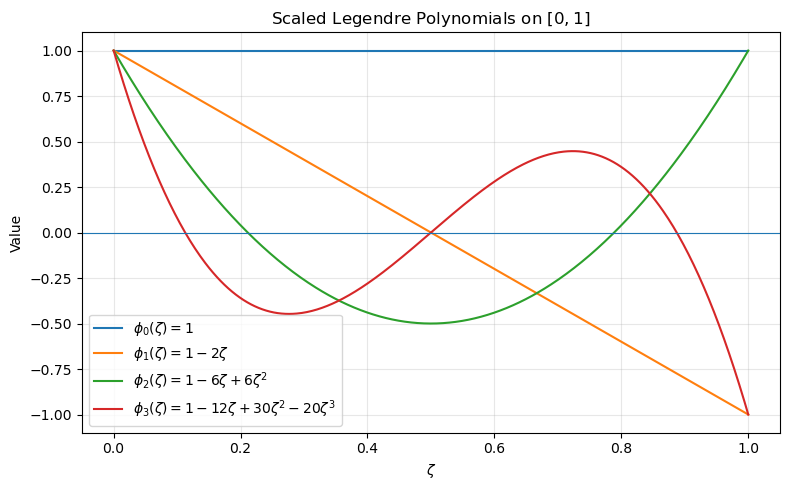

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# First four scaled Legendre polynomials on zeta in [0, 1]
def phi0(zeta):
    return np.ones_like(zeta)

def phi1(zeta):
    return 1.0 - 2.0 * zeta

def phi2(zeta):
    return 1.0 - 6.0 * zeta + 6.0 * zeta**2

def phi3(zeta):
    return 1.0 - 12.0 * zeta + 30.0 * zeta**2 - 20.0 * zeta**3

# Grid
zeta = np.linspace(0.0, 1.0, 500)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(zeta, phi0(zeta), label=r'$\phi_0(\zeta)=1$')
plt.plot(zeta, phi1(zeta), label=r'$\phi_1(\zeta)=1-2\zeta$')
plt.plot(zeta, phi2(zeta), label=r'$\phi_2(\zeta)=1-6\zeta+6\zeta^2$')
plt.plot(zeta, phi3(zeta), label=r'$\phi_3(\zeta)=1-12\zeta+30\zeta^2-20\zeta^3$')

plt.xlabel(r'$\zeta$')
plt.ylabel('Value')
plt.title('Scaled Legendre Polynomials on $[0,1]$')
plt.axhline(0.0, linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Zeroth moments: compute the averaged quadratic terms

We first compute the flux terms in the averaged equations.

#### 4.2.1 Compute $\int_0^1 \widetilde u^2\,d\zeta$

Expand:
$$
\widetilde u^2
=
\left(u_m+\sum_{j=1}^N \alpha_j\phi_j\right)^2
=
u_m^2
+2u_m\sum_{j=1}^N \alpha_j\phi_j
+\sum_{j,k=1}^N \alpha_j\alpha_k\phi_j\phi_k.
$$

Integrate over $\zeta$:
$$
\int_0^1 \widetilde u^2\,d\zeta
=
u_m^2
+2u_m\sum_{j=1}^N \alpha_j\int_0^1\phi_j\,d\zeta
+\sum_{j,k=1}^N \alpha_j\alpha_k\int_0^1\phi_j\phi_k\,d\zeta.
$$

Since $\int_0^1\phi_j\,d\zeta=0$ and the basis is orthogonal,
$$
\int_0^1 \widetilde u^2\,d\zeta
=
u_m^2+\sum_{j=1}^N \frac{\alpha_j^2}{2j+1}.
$$

#### 4.2.2 Compute $\int_0^1 \widetilde u\widetilde v\,d\zeta$

Similarly,
$$
\widetilde u\widetilde v
=
\left(u_m+\sum_{j=1}^N \alpha_j\phi_j\right)
\left(v_m+\sum_{k=1}^N \beta_k\phi_k\right).
$$

Integrating and using orthogonality gives
$$
\int_0^1 \widetilde u\widetilde v\,d\zeta
=
u_m v_m+\sum_{j=1}^N \frac{\alpha_j\beta_j}{2j+1}.
$$

Likewise,
$$
\int_0^1 \widetilde v^2\,d\zeta
=
v_m^2+\sum_{j=1}^N \frac{\beta_j^2}{2j+1}.
$$

#### 4.2.3 Compute the bottom values

Because $\phi_j(0)=1$,
$$
\widetilde u(0)=u_m+\sum_{j=1}^N \alpha_j,
\qquad
\widetilde v(0)=v_m+\sum_{j=1}^N \beta_j.
$$

Substitute into the averaged equations:

$$
\boxed{
\partial_t h+\partial_x(h u_m)+\partial_y(h v_m)=0,
}
$$

$$
\boxed{
\partial_t(h u_m)
+\partial_x\!\left(h\left(u_m^2+\sum_{j=1}^N \frac{\alpha_j^2}{2j+1}\right)+\frac{G}{2}h^2\right)
+\partial_y\!\left(h\left(u_m v_m+\sum_{j=1}^N \frac{\alpha_j\beta_j}{2j+1}\right)\right)
=
-\frac{\gamma}{\varepsilon}\left(u_m+\sum_{j=1}^N \alpha_j\right)-Gh\,\partial_x h_b,
}
$$

$$
\boxed{
\partial_t(h v_m)
+\partial_x\!\left(h\left(u_m v_m+\sum_{j=1}^N \frac{\alpha_j\beta_j}{2j+1}\right)\right)
+\partial_y\!\left(h\left(v_m^2+\sum_{j=1}^N \frac{\beta_j^2}{2j+1}\right)+\frac{G}{2}h^2\right)
=
-\frac{\gamma}{\varepsilon}\left(v_m+\sum_{j=1}^N \beta_j\right)-Gh\,\partial_y h_b.
}
$$

### 4.3. Higher moments: projection with $\phi_i$

Now derive equations for $\alpha_i$ and $\beta_i$.

The key observation is
$$
\int_0^1 \phi_i \widetilde u\,d\zeta
=
\int_0^1 \phi_i\left(u_m+\sum_{j=1}^N \alpha_j\phi_j\right)\,d\zeta
=
\frac{\alpha_i}{2i+1},
$$
and similarly
$$
\int_0^1 \phi_i \widetilde v\,d\zeta
=
\frac{\beta_i}{2i+1}.
$$

So the $i$-th moment equation is obtained by

- multiplying the mapped $u$-momentum equation by $\phi_i$,
- integrating over $\zeta\in[0,1]$,
- multiplying the whole result by $(2i+1)$.

### 4.4 Time derivative term

Start with
$$
(2i+1)\int_0^1 \phi_i\,\partial_t(h\widetilde u)\,d\zeta.
$$

Since $\phi_i$ depends only on $\zeta$,
$$
(2i+1)\int_0^1 \phi_i\,\partial_t(h\widetilde u)\,d\zeta
=
\partial_t\left((2i+1)\int_0^1 \phi_i\,h\widetilde u\,d\zeta\right)
=
\partial_t(h\alpha_i).
$$

Likewise for $v$:
$$
(2i+1)\int_0^1 \phi_i\,\partial_t(h\widetilde v)\,d\zeta
=
\partial_t(h\beta_i).
$$

### 4.5 Convective fluxes

Define
$$
A_{ijk}
:=
(2i+1)\int_0^1 \phi_i(\zeta)\phi_j(\zeta)\phi_k(\zeta)\,d\zeta.
$$

#### 4.5.1 The $u^2$ term

Compute
$$
(2i+1)\int_0^1 \phi_i \widetilde u^2\,d\zeta.
$$

Using
$$
\widetilde u=u_m+\sum_{j=1}^N \alpha_j\phi_j,
$$
we have
$$
\widetilde u^2
=
u_m^2+2u_m\sum_{j=1}^N \alpha_j\phi_j+\sum_{j,k=1}^N \alpha_j\alpha_k\phi_j\phi_k.
$$

Multiply by $\phi_i$ and integrate:
- the $u_m^2$ term vanishes because $\int_0^1 \phi_i\,d\zeta=0$,
- the linear term gives
  $$
  (2i+1)\int_0^1 2u_m\alpha_i \phi_i^2\,d\zeta = 2u_m\alpha_i,
  $$
- the quadratic term gives
  $$
  \sum_{j,k=1}^N A_{ijk}\alpha_j\alpha_k.
  $$

So
$$
(2i+1)\int_0^1 \phi_i \widetilde u^2\,d\zeta
=
2u_m\alpha_i+\sum_{j,k=1}^N A_{ijk}\alpha_j\alpha_k.
$$

Hence
$$
(2i+1)\int_0^1 \phi_i\,\partial_x(h\widetilde u^2)\,d\zeta
=
\partial_x\!\left(h\left(2u_m\alpha_i+\sum_{j,k=1}^N A_{ijk}\alpha_j\alpha_k\right)\right).
$$

#### 4.5.2 The $uv$ term

Similarly,
$$
(2i+1)\int_0^1 \phi_i \widetilde u\widetilde v\,d\zeta
=
u_m\beta_i+v_m\alpha_i+\sum_{j,k=1}^N A_{ijk}\alpha_j\beta_k.
$$

Thus
$$
(2i+1)\int_0^1 \phi_i\,\partial_y(h\widetilde u\widetilde v)\,d\zeta
=
\partial_y\!\left(h\left(u_m\beta_i+v_m\alpha_i+\sum_{j,k=1}^N A_{ijk}\alpha_j\beta_k\right)\right).
$$

The corresponding $v$-equation gives
$$
(2i+1)\int_0^1 \phi_i \widetilde v^2\,d\zeta
=
2v_m\beta_i+\sum_{j,k=1}^N A_{ijk}\beta_j\beta_k.
$$

So the pure convective parts are done.

### 4.6 Vertical coupling term

This is the most delicate part.

From the mapped mass equation, the vertical coupling can be written as
$$
h\omega
=
-\partial_x\!\left(h\int_0^\zeta (\widetilde u-u_m)\,d\widehat\zeta\right)
-\partial_y\!\left(h\int_0^\zeta (\widetilde v-v_m)\,d\widehat\zeta\right).
$$

Since
$$
\widetilde u-u_m=\sum_{j=1}^N \alpha_j\phi_j,
\qquad
\widetilde v-v_m=\sum_{j=1}^N \beta_j\phi_j,
$$
define
$$
D_j:=\partial_x(h\alpha_j)+\partial_y(h\beta_j).
$$

Then
$$
h\omega
=
-\sum_{j=1}^N D_j \int_0^\zeta \phi_j(\widehat\zeta)\,d\widehat\zeta.
$$

Now define
$$
B_{ijk}
:=
(2i+1)\int_0^1 \phi_i'(\zeta)\left(\int_0^\zeta \phi_j(\widehat\zeta)\,d\widehat\zeta\right)\phi_k(\zeta)\,d\zeta.
$$

We now compute
$$
(2i+1)\int_0^1 \phi_i\,\partial_\zeta(\widetilde u\,h\omega)\,d\zeta.
$$

Integrate by parts in $\zeta$. Since $\phi_i$ is finite and $h\omega=0$ at $\zeta=0,1$, the boundary terms vanish, so
$$
(2i+1)\int_0^1 \phi_i\,\partial_\zeta(\widetilde u\,h\omega)\,d\zeta
=
-(2i+1)\int_0^1 \phi_i' \widetilde u\,h\omega\,d\zeta.
$$

Insert
$$
\widetilde u=u_m+\sum_{k=1}^N \alpha_k\phi_k,
\qquad
h\omega
=
-\sum_{j=1}^N D_j \int_0^\zeta \phi_j(\widehat\zeta)\,d\widehat\zeta.
$$

Then
$$
-(2i+1)\int_0^1 \phi_i' \widetilde u\,h\omega\,d\zeta
=
(2i+1)\int_0^1 \phi_i'
\left(u_m+\sum_{k=1}^N \alpha_k\phi_k\right)
\left(\sum_{j=1}^N D_j \int_0^\zeta \phi_j(\widehat\zeta)\,d\widehat\zeta\right)\,d\zeta.
$$

Split the terms.

#### 4.6.1 The mean part

For the $u_m$ part,
$$
(2i+1)u_m\sum_{j=1}^N D_j
\int_0^1 \phi_i'(\zeta)\left(\int_0^\zeta \phi_j(\widehat\zeta)\,d\widehat\zeta\right)\,d\zeta.
$$

This reduces to
$$
u_m D_i.
$$

#### 4.6.2 The fluctuation part

The remaining part is
$$
-\sum_{j,k=1}^N B_{ijk}D_j\alpha_k.
$$

So altogether,
$$
(2i+1)\int_0^1 \phi_i\,\partial_\zeta(\widetilde u\,h\omega)\,d\zeta
=
u_m D_i-\sum_{j,k=1}^N B_{ijk}D_j\alpha_k.
$$

Similarly,
$$
(2i+1)\int_0^1 \phi_i\,\partial_\zeta(\widetilde v\,h\omega)\,d\zeta
=
v_m D_i-\sum_{j,k=1}^N B_{ijk}D_j\beta_k.
$$

This is exactly the nonconservative coupling structure in the moment equations.

### 4.7 Viscous / friction term

Now treat
$$
-(2i+1)\int_0^1 \phi_i\,\partial_\zeta\!\left(\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\right)\,d\zeta.
$$

Integrate by parts:
$$
-(2i+1)\left[
\phi_i\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u
\right]_{\zeta=0}^{\zeta=1}
+
(2i+1)\int_0^1 \phi_i' \frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u\,d\zeta.
$$

At the top, $\partial_\zeta \widetilde u(1)=0$.

At the bottom,
$$
\frac{{\mathrm Re}^{-1}_0}{h}\partial_\zeta \widetilde u(0)=\frac{\gamma}{\varepsilon}\widetilde u(0)
=
\frac{\gamma}{\varepsilon}\left(u_m+\sum_{j=1}^N \alpha_j\right),
$$
and since $\phi_i(0)=1$, the boundary contribution is
$$
-(2i+1)\frac{\gamma}{\varepsilon}\left(u_m+\sum_{j=1}^N \alpha_j\right).
$$

Now define
$$
C_{ij}:=\int_0^1 \phi_i'(\zeta)\phi_j'(\zeta)\,d\zeta.
$$

Since
$$
\partial_\zeta \widetilde u
=
\sum_{j=1}^N \alpha_j\phi_j',
$$
the interior integral becomes
$$
(2i+1)\frac{{\mathrm Re}^{-1}_0}{h}\sum_{j=1}^N C_{ij}\alpha_j.
$$

Therefore the total viscous term is
$$
-(2i+1)\frac{\gamma}{\varepsilon}\left(u_m+\sum_{j=1}^N \alpha_j\right)
-(2i+1)\frac{{\mathrm Re}^{-1}_0}{h}\sum_{j=1}^N C_{ij}\alpha_j.
$$

Factor out $-(2i+1)\gamma/\varepsilon$:
$$
-(2i+1)\frac{\gamma}{\varepsilon}
\left(
u_m+\sum_{j=1}^N
\left(1+\frac{\varepsilon {\mathrm Re}^{-1}_0}{h\gamma}C_{ij}\right)\alpha_j
\right).
$$

The $v$-equation gives
$$
-(2i+1)\frac{\gamma}{\varepsilon}
\left(
v_m+\sum_{j=1}^N
\left(1+\frac{\varepsilon {\mathrm Re}^{-1}_0}{h\gamma}C_{ij}\right)\beta_j
\right).
$$

### 4.8 Final higher-moment equations

Collect everything.

For $i=1,\dots,N$,
$$
\boxed{
\partial_t(h\alpha_i)
+\partial_x\!\left(
h\left(2u_m\alpha_i+\sum_{j,k=1}^N A_{ijk}\alpha_j\alpha_k\right)
\right)
+\partial_y\!\left(
h\left(u_m\beta_i+v_m\alpha_i+\sum_{j,k=1}^N A_{ijk}\alpha_j\beta_k\right)
\right)
}
$$
$$
\boxed{
=
u_m D_i
-\sum_{j,k=1}^N B_{ijk}D_j\alpha_k
-(2i+1)\frac{\gamma}{\varepsilon}
\left(
u_m+\sum_{j=1}^N
\left(1+\frac{\varepsilon{\mathrm Re}^{-1}_0}{h\gamma}C_{ij}\right)\alpha_j
\right),
}
$$
with
$$
D_i=\partial_x(h\alpha_i)+\partial_y(h\beta_i).
$$

Similarly,
$$
\boxed{
\partial_t(h\beta_i)
+\partial_x\!\left(
h\left(u_m\beta_i+v_m\alpha_i+\sum_{j,k=1}^N A_{ijk}\alpha_j\beta_k\right)
\right)
+\partial_y\!\left(
h\left(2v_m\beta_i+\sum_{j,k=1}^N A_{ijk}\beta_j\beta_k\right)
\right)
}
$$
$$
\boxed{
=
v_m D_i
-\sum_{j,k=1}^N B_{ijk}D_j\beta_k
-(2i+1)\frac{\gamma}{\varepsilon}
\left(
v_m+\sum_{j=1}^N
\left(1+\frac{\varepsilon{\mathrm Re}^{-1}_0}{h\gamma}C_{ij}\right)\beta_j
\right).
}
$$

Together with the mean equations, this is the full SWME system in our notation.

---


For clarity,
$$
A_{ijk}
=
(2i+1)\int_0^1 \phi_i\phi_j\phi_k\,d\zeta,
$$
$$
B_{ijk}
=
(2i+1)\int_0^1 \phi_i'
\left(\int_0^\zeta \phi_j(\widehat\zeta)\,d\widehat\zeta\right)\phi_k\,d\zeta,
$$
$$
C_{ij}
=
\int_0^1 \phi_i'\phi_j'\,d\zeta,
$$
$$
D_i=\partial_x(h\alpha_i)+\partial_y(h\beta_i).
$$

---

A clean way to view the whole derivation is:

- **mean equations** come from integrating the vertically resolved equations,
- **higher moments** come from projecting against $\phi_i$,
- **$A_{ijk}$** come from the quadratic convective products,
- **$B_{ijk}$** come from the vertical coupling term,
- **$C_{ij}$** come from integration by parts of the viscous term,
- the stiff source comes from the **bottom boundary condition**.

## 5. 1D SWME examples with $N=0,1,2$

We consider the one-dimensional case with flat bottom $h_b=\mathrm{const}$, so the topography source term vanishes. We use conserved variables and write the systems in the form
$$
\partial_t U + \partial_x F(U) = Q(U)\,\partial_x U + S(U).
$$

Here
$$
u_m=\frac{hu_m}{h},\qquad \alpha_j=\frac{h\alpha_j}{h}.
$$

---

### 1. Case $N=0$

The unknown vector is
$$
U^{(0)}=
\begin{pmatrix}
h\\[2mm]
hu_m
\end{pmatrix}.
$$

The system is purely conservative:
$$
Q^{(0)}(U)=
\begin{pmatrix}
0&0\\
0&0
\end{pmatrix}.
$$

The flux is
$$
F^{(0)}(U)=
\begin{pmatrix}
hu_m\\[2mm]
h u_m^2+\dfrac{G}{2}h^2
\end{pmatrix}.
$$

The source term is
$$
S^{(0)}(U)=
-\frac{\gamma}{\varepsilon}
\begin{pmatrix}
0\\[2mm]
u_m
\end{pmatrix}.
$$

So the system is
$$
\partial_t
\begin{pmatrix}
h\\
hu_m
\end{pmatrix}
+
\partial_x
\begin{pmatrix}
hu_m\\[2mm]
h u_m^2+\dfrac{G}{2}h^2
\end{pmatrix}
=
-\frac{\gamma}{\varepsilon}
\begin{pmatrix}
0\\[2mm]
u_m
\end{pmatrix}.
$$

---

### 2. Case $N=1$

Now the velocity profile is
$$
\widetilde u(\zeta)=u_m+\alpha_1\phi_1(\zeta),
\qquad
\phi_1(\zeta)=1-2\zeta.
$$

The unknown vector is
$$
U^{(1)}=
\begin{pmatrix}
h\\[2mm]
hu_m\\[2mm]
h\alpha_1
\end{pmatrix}.
$$

The flux is
$$
F^{(1)}(U)=
\begin{pmatrix}
hu_m\\[2mm]
h\left(u_m^2+\dfrac{\alpha_1^2}{3}\right)+\dfrac{G}{2}h^2\\[2mm]
2h u_m\alpha_1
\end{pmatrix}.
$$

The nonconservative matrix is
$$
Q^{(1)}(U)=
\begin{pmatrix}
0&0&0\\
0&0&0\\
0&0&u_m
\end{pmatrix}.
$$

The source term is
$$
S^{(1)}(U)=
-\frac{\gamma}{\varepsilon}
\begin{pmatrix}
0\\[2mm]
u_m+\alpha_1\\[2mm]
3\left(u_m+\left(1+4\frac{\varepsilon{\mathrm Re}^{-1}_0}{h\gamma}\right)\alpha_1\right)
\end{pmatrix}.
$$

So the system is
$$
\partial_t
\begin{pmatrix}
h\\
hu_m\\
h\alpha_1
\end{pmatrix}
+
\partial_x
\begin{pmatrix}
hu_m\\[2mm]
h\left(u_m^2+\dfrac{\alpha_1^2}{3}\right)+\dfrac{G}{2}h^2\\[2mm]
2h u_m\alpha_1
\end{pmatrix}
=
\begin{pmatrix}
0&0&0\\
0&0&0\\
0&0&u_m
\end{pmatrix}
\partial_x
\begin{pmatrix}
h\\
hu_m\\
h\alpha_1
\end{pmatrix}
-\frac{\gamma}{\varepsilon}
\begin{pmatrix}
0\\[2mm]
u_m+\alpha_1\\[2mm]
3\left(u_m+\left(1+4\frac{\varepsilon{\mathrm Re}^{-1}_0}{h\gamma}\right)\alpha_1\right)
\end{pmatrix}.
$$

---

### 3. Case $N=2$

Now the velocity profile is
$$
\widetilde u(\zeta)=u_m+\alpha_1\phi_1(\zeta)+\alpha_2\phi_2(\zeta),
$$
with
$$
\phi_1(\zeta)=1-2\zeta,
\qquad
\phi_2(\zeta)=1-6\zeta+6\zeta^2.
$$

The unknown vector is
$$
U^{(2)}=
\begin{pmatrix}
h\\[2mm]
hu_m\\[2mm]
h\alpha_1\\[2mm]
h\alpha_2
\end{pmatrix}.
$$

The flux is
$$
F^{(2)}(U)=
\begin{pmatrix}
hu_m\\[2mm]
h\left(u_m^2+\dfrac{\alpha_1^2}{3}+\dfrac{\alpha_2^2}{5}\right)+\dfrac{G}{2}h^2\\[3mm]
h\left(2u_m\alpha_1+\dfrac{4}{5}\alpha_1\alpha_2\right)\\[3mm]
h\left(2u_m\alpha_2+\dfrac{2}{3}\alpha_1^2+\dfrac{2}{7}\alpha_2^2\right)
\end{pmatrix}.
$$

The nonconservative matrix is
$$
Q^{(2)}(U)=
\begin{pmatrix}
0&0&0&0\\
0&0&0&0\\
0&0&u_m-\dfrac{\alpha_2}{5}&\dfrac{\alpha_1}{5}\\[3mm]
0&0&\alpha_1&u_m+\dfrac{\alpha_2}{7}
\end{pmatrix}.
$$

The source term is
$$
S^{(2)}(U)=
-\frac{\gamma}{\varepsilon}
\begin{pmatrix}
0\\[2mm]
u_m+\alpha_1+\alpha_2\\[2mm]
3\left(u_m+\left(1+4\frac{\varepsilon{\mathrm Re}^{-1}_0}{h\gamma}\right)\alpha_1+\alpha_2\right)\\[3mm]
5\left(u_m+\alpha_1+\left(1+12\frac{\varepsilon{\mathrm Re}^{-1}_0}{h\gamma}\right)\alpha_2\right)
\end{pmatrix}.
$$

So the system is
$$
\partial_t
\begin{pmatrix}
h\\
hu_m\\
h\alpha_1\\
h\alpha_2
\end{pmatrix}
+
\partial_x
\begin{pmatrix}
hu_m\\[2mm]
h\left(u_m^2+\dfrac{\alpha_1^2}{3}+\dfrac{\alpha_2^2}{5}\right)+\dfrac{G}{2}h^2\\[3mm]
h\left(2u_m\alpha_1+\dfrac{4}{5}\alpha_1\alpha_2\right)\\[3mm]
h\left(2u_m\alpha_2+\dfrac{2}{3}\alpha_1^2+\dfrac{2}{7}\alpha_2^2\right)
\end{pmatrix}
=
Q^{(2)}(U)\,
\partial_x
\begin{pmatrix}
h\\
hu_m\\
h\alpha_1\\
h\alpha_2
\end{pmatrix}
+
S^{(2)}(U).
$$

## 6. Hyperbolicity modifications ...

In [2]:

# %matplotlib inline

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 22

matplotlib.rc('font', size=SMALL_SIZE)
matplotlib.rc('axes', titlesize=MEDIUM_SIZE)
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)
matplotlib.rc('xtick', labelsize=SMALL_SIZE)
matplotlib.rc('ytick', labelsize=SMALL_SIZE)
matplotlib.rc('legend', fontsize=SMALL_SIZE)
matplotlib.rc('figure', titlesize=BIGGER_SIZE)


# The 1D hyperbolic shallow water moment equations

The hyperbolic shallow water moment equation (HSWME) can be written as
$$
\partial_{t}U + A^{N}_{H}(U)\partial_{x}U = S^{N}_{\rm SWME}(U)
$$
by **linearizing the system matrix $A$**
$$
A_{H}^{N}(U) = A(h, hu_m, h\alpha_1, 0,...,0),
$$


Below, we write the coefficient matrices recursively, so that each higher-order matrix is expressed as the previous one plus an additional block contribution.


- Case $N=0$

Unknown:
$$
U=
\begin{pmatrix}
h\\
hu_m
\end{pmatrix}.
$$

The coefficient matrix is
$$
A_H^{0}(U)=
\begin{pmatrix}
0 & 1\\[1mm]
-u_m^2+Gh & 2u_m
\end{pmatrix}.
$$


- Case $N=1$

Unknown:
$$
U=
\begin{pmatrix}
h\\
hu_m\\
h\alpha_1
\end{pmatrix}.
$$

We write
$$
A_H^{1}(U)=
\begin{pmatrix}
0 & 1 & 0\\[1mm]
-u_m^2+Gh-\dfrac{\alpha_1^2}{3} & 2u_m & \dfrac{2\alpha_1}{3}\\[3mm]
-2u_m\alpha_1 & 2\alpha_1 & u_m
\end{pmatrix}=
\begin{pmatrix}
A_H^{0}(U) & 0\\
0 & 0
\end{pmatrix}
+
\begin{pmatrix}
0 & 0 & 0\\[1mm]
-\dfrac{\alpha_1^2}{3} & 0 & \dfrac{2\alpha_1}{3}\\[3mm]
-2u_m\alpha_1 & 2\alpha_1 & u_m
\end{pmatrix}.
$$


- Case $N=2$

Unknown:
$$
U=
\begin{pmatrix}
h\\
hu_m\\
h\alpha_1\\
h\alpha_2
\end{pmatrix}.
$$

We write
$$
A_H^{2}(U)=
\begin{pmatrix}
0 & 1 & 0 & 0\\[1mm]
-u_m^2+Gh-\dfrac{\alpha_1^2}{3} & 2u_m & \dfrac{2\alpha_1}{3} & 0\\[3mm]
-2u_m\alpha_1 & 2\alpha_1 & u_m & \dfrac{3\alpha_1}{5}\\[3mm]
-\dfrac{2}{3}\alpha_1^2 & 0 & \dfrac{\alpha_1}{3} & u_m
\end{pmatrix}=
\begin{pmatrix}
A_H^{1}(U) & 0\\
0 & 0
\end{pmatrix}
+
\begin{pmatrix}
0 & 0 & 0 & 0\\[1mm]
0 & 0 & 0 & 0\\[1mm]
0 & 0 & 0 & \dfrac{3\alpha_1}{5}\\[3mm]
-\dfrac{2}{3}\alpha_1^2 & 0 & \dfrac{\alpha_1}{3} & u_m
\end{pmatrix}.
$$



# $\Downarrow$ Edit These Functions $\Downarrow$

Suggested cells to edit :

- `compute_jacobian`


In [3]:
def compute_jacobian(U, gravity, model_type='HSWME'):
    """
    Compute the x-direction Jacobian A_H(U) used by the Roe-type discretization.

    Parameters
    ----------
    U : ndarray, shape (var_num,)
        Conservative state vector at one point:
        U = [h, h*u_m, h*alpha_1, h*alpha_2, ...]
    gravity : float
        Dimensionless gravity G.
    model_type : str
        Kept for compatibility with the uploaded code.

    Returns
    -------
    A : ndarray, shape (var_num, var_num)
        Jacobian matrix A_H(U).
    """
    var_num = len(U)
    order_moment = var_num - 2
    A = np.zeros((var_num, var_num), dtype=float)

    # Conservative variables
    "???"
    "???"

    # Primitive variables
    "???"

    # N = 0 block
    A[0, 0] = "???"
    A[0, 1] = "???"
    A[1, 0] = "???"
    A[1, 1] = "???"

    # N = 1 contributions
    if order_moment >= 1:

        A[1, 0] += "???"
        A[1, 2] += "???"
        A[2, 0] += "???"
        A[2, 1] += "???"
        A[2, 2] += "???"

    # N = 2 contributions in the hyperbolic shallow water moment style
    if order_moment == 2 and model_type == 'HSWME':
        # alpha_1 already defined above
        A[2, 3] += "???"
        A[3, 0] += "???"
        A[3, 2] += "???"
        A[3, 3] += "???"

    return A


# The 1D Modified Shallow Water Moment Equations

We consider the 1D dam-break setting for the shallow water / shallow water moment systems.
In conserved variables,
$$
\mathbf U =
\begin{pmatrix}
 h \\
 h u_m \\
 h\alpha_1 \\
 h\alpha_2
\end{pmatrix},
$$
with truncation according to the chosen order $N=0,1,2$.

For the **modified** models, the source terms are
$$
S^{0}_{\mathrm{modified}}(\mathbf U)
=
-\bar\gamma
\begin{pmatrix}
0 \\
 u_m
\end{pmatrix},
$$
$$
S^{1}_{\mathrm{modified}}(\mathbf U) = -\bar\gamma
\begin{pmatrix}
0 \\
 u_m \\
 3\left(u_m + 4\dfrac{{\mathrm Re}^{-1}_0}{h\bar\gamma}\alpha_1\right)
\end{pmatrix},
$$
$$
S^{2}_{\mathrm{modified}}(\mathbf U)
=
-\bar\gamma
\begin{pmatrix}
0 \\
 u_m \\
 3\left(u_m + 4\dfrac{{\mathrm Re}^{-1}_0}{h\bar\gamma}\alpha_1\right) \\
 5\left(u_m + 12\dfrac{{\mathrm Re}^{-1}_0}{h\bar\gamma}\alpha_2\right)
\end{pmatrix},
$$
where
$$
\bar\gamma = \frac{\gamma}{\varepsilon\left(1+\dfrac{h\gamma}{2\varepsilon{\mathrm Re}^{-1}_0}\right)}.
$$

This notebook rewrites the Python solver into a notebook workflow following the style of the uploaded template: editable core functions first, then the run cells and plotting cells below.


In [4]:


def initialize_state(nx, h_left, h_right, var_num, case='init', u_scale=1.0, h_scale=1.0):
    """
    Initialize the state vector for the 1D dam-break problem.

    Parameters
    ----------
    nx : int
        Number of computational cells.
    h_left, h_right : float
        Initial dimensionless water heights on the left and right states.
    var_num : int
        Number of conserved variables.
        2 -> MSWE / SWE: [h, hu]
        3 -> first-order (M)SWME: [h, hu, h*alpha_1]
        4 -> second-order (M)SWME: [h, hu, h*alpha_1, h*alpha_2]
    case : str
        Initialization tag. The current default 'init' matches the uploaded code.
    u_scale, h_scale : float
        Dimensional scaling values used in the existing initialization.

    Returns
    -------
    state : ndarray, shape (nx, var_num)
        Conserved variables cell by cell.
    """
    state = np.zeros((nx, var_num), dtype=float)

    # Dam-break height field
    state[:, 0] = h_right
    state[:nx // 2, 0] = h_left

    # Initial mean velocity and moments (matching the uploaded script)
    if var_num == 2:
        state[:, 1] = 0.125 * state[:, 0]**2 * h_scale / u_scale

    elif var_num == 3 and case == 'init':
        state[:, 1] = 0.125 * state[:, 0]**2 * h_scale / u_scale
        state[:, 2] = -0.125 * state[:, 0]**2 * h_scale / u_scale

    elif var_num == 4 and case == 'init':
        state[:, 1] = 0.125 * state[:, 0]**2 * h_scale / u_scale
        state[:, 2] = -0.125 * state[:, 0]**2 * h_scale / u_scale
        state[:, 3] = 0.0

    return state



def compute_source_term(state, epsilon, alpha0, r0, model_type='modified'):
    """
    Compute the source term.

    Parameters
    ----------
    state : ndarray, shape (nx, var_num)
    epsilon : float
        Aspect ratio H1 / L1.
    alpha0 : float
        Dimensionless friction parameter.
    r0 : float
        Dimensionless viscosity parameter iRe_0.
    model_type : str
        'original' or 'modified'. The notebook focuses on 'modified'.

    Returns
    -------
    source : ndarray, shape (nx, var_num)
    """
    nx, var_num = state.shape
    order_moment = var_num - 2
    source = np.zeros((nx, var_num), dtype=float)

    h = state[:, 0]
    hu = state[:, 1]
    u = hu / h

    if model_type == 'original':
        alpha_sum = np.sum(state[:, 2:] / h[:, None], axis=1) if order_moment > 0 else 0.0
        coe0 = alpha0
        coe11 = 1.0 + 4.0 * r0 / h / epsilon / alpha0
        coe12 = 1.0
        coe21 = 1.0
        coe22 = 1.0 + 12.0 * r0 / h / epsilon / alpha0

    elif model_type == 'modified':
        alpha_sum = 0.0
        coe0 = alpha0 / (1.0 + h * epsilon * alpha0 / (2.0 * r0))
        coe11 = 4.0 * r0 / h / epsilon / coe0
        coe12 = 0.0
        coe21 = 0.0
        coe22 = 12.0 * r0 / h / epsilon / coe0

    else:
        raise ValueError("model_type must be 'original' or 'modified'.")

    # Mean momentum source
    source[:, 1] = -coe0 * (u + alpha_sum)

    # Moment sources
    if order_moment == 1:
        alpha1 = state[:, 2] / h
        source[:, 2] = -3.0 * coe0 * (u + coe11 * alpha1)

    elif order_moment == 2:
        alpha1 = state[:, 2] / h
        alpha2 = state[:, 3] / h
        source[:, 2] = -3.0 * coe0 * (u + coe11 * alpha1 + coe12 * alpha2)
        source[:, 3] = -5.0 * coe0 * (u + coe21 * alpha1 + coe22 * alpha2)

    return source


def compute_max_eigenvalue(state, gravity):
    """
    Compute the maximum characteristic speed used in the CFL condition.
    """
    var_num = len(state)
    order_moment = var_num - 2

    h = state[0]
    if h <= 0.0:
        raise ValueError(f"Water height h must be positive, got {h}")

    u = state[1] / h
    alpha_1 = 0.0
    if order_moment > 0:
        alpha_1 = state[2] / h

    return np.abs(u) + np.sqrt(gravity * h + alpha_1**2)


def roe_scheme_1d(state, gravity, dx, dt):
    """
    Roe-type spatial discretization.

    Parameters
    ----------
    state : ndarray, shape (nx, var_num)
    gravity : float
    dx, dt : float

    Returns
    -------
    rhs : ndarray, shape (nx, var_num)
        Semi-discrete update contribution.
    """
    nx, var_num = state.shape
    rhs = np.zeros_like(state)

    roe_states = np.zeros_like(state)
    max_wavespeed = np.zeros(nx)
    jacobians = []

    for i in range(nx):
        i_plus = min(i + 1, nx - 1)
        roe_states[i, :] = 0.5 * (state[i, :] + state[i_plus, :])
        max_wavespeed[i] = compute_max_eigenvalue(roe_states[i, :], gravity)
        jacobians.append(compute_jacobian(roe_states[i, :], gravity))

    for i in range(1, nx - 1):
        i_minus = i - 1
        i_plus = i + 1

        for j in range(var_num):
            matrix_contrib = 0.0
            for k in range(var_num):
                term_left = jacobians[i_minus][j, k] * (state[i, k] - state[i_minus, k])
                term_right = jacobians[i][j, k] * (state[i_plus, k] - state[i, k])
                matrix_contrib += -dt / (2.0 * dx) * (term_left + term_right)

            delta_left = state[i, j] - state[i_minus, j]
            delta_right = state[i_plus, j] - state[i, j]
            wave_contrib = -dt / (2.0 * dx) * (
                max_wavespeed[i_minus] * delta_left - max_wavespeed[i] * delta_right
            )

            rhs[i, j] = matrix_contrib + wave_contrib

    return rhs


def swme_solver(u_scale, h_scale, h_left, h_right, length, gravity, nx, cfl,
                time_end, alpha0, r0, epsilon, model_type='modified',
                var_num=3, t_target=None, initial_case='init', verbose=True):
    """
    Main 1D solver for the shallow water / moment systems.

    Parameters
    ----------
    u_scale, h_scale : float
        Dimensional scales used by the uploaded initialization.
    h_left, h_right : float
        Dimensionless left/right dam heights.
    length : float
        Computational domain length.
    gravity : float
        Dimensionless gravity G.
    nx : int
        Number of grid cells.
    cfl : float
        CFL number.
    time_end : float
        Final dimensionless time.
    alpha0, r0, epsilon : float
        Dimensionless friction / viscosity / aspect-ratio parameters.
    model_type : str
        'original' or 'modified'.
    var_num : int
        2, 3, or 4.
    t_target : list[float] or None
        Optional target output times.
    initial_case : str
        Initialization tag.
    verbose : bool
        Print progress information.

    Returns
    -------
    U_history : list of ndarray
    dt_history : list of float
    """
    dx = length / nx
    state = initialize_state(nx, h_left, h_right, var_num, initial_case, u_scale, h_scale)

    U_history = [state.copy()]
    dt_history = []

    t_curr = 0.0
    time_step = 0
    target_idx = 0
    t_target = [] if t_target is None else list(t_target)

    if verbose:
        print(f"Starting simulation: model={model_type}, var_num={var_num}")
        print(f"Domain: nx={nx}, dx={dx:.4e}, CFL={cfl}")
        print(f"Parameters: alpha0={alpha0:.4e}, R0={r0:.4e}, epsilon={epsilon:.4e}")
        print('-' * 70)

    while t_curr < time_end - 1.0e-14:
        wavespeed = np.array([compute_max_eigenvalue(state[i, :], gravity) for i in range(nx)])
        max_wavespeed = np.max(wavespeed)
        dt = cfl * dx / max_wavespeed
        dt = min(dt, time_end - t_curr)

        if target_idx < len(t_target) and dt > t_target[target_idx] - t_curr:
            dt = t_target[target_idx] - t_curr
            t_curr = t_target[target_idx]
            target_idx += 1
        else:
            t_curr += dt

        time_step += 1
        dt_history.append(dt)

        rhs = roe_scheme_1d(state, gravity, dx, dt)
        source = compute_source_term(state, epsilon, alpha0, r0, model_type=model_type)

        # Time update
        if var_num == 2 and model_type == 'original':
            state[:, 0] += rhs[:, 0]
            state[:, 1] = (state[:, 1] + rhs[:, 1]) / (1.0 + dt * alpha0 / state[:, 0])

        elif var_num == 3 and model_type == 'original':
            h = state[:, 0].copy()
            for i in range(1, nx - 1):
                state[i, 0] += rhs[i, 0] + source[i, 0] * dt

                a11 = 1.0 + dt * alpha0 / h[i]
                a12 = dt * alpha0 / h[i]
                a21 = 3.0 * dt * alpha0 / h[i]
                a22 = 1.0 + dt * alpha0 / h[i] * (3.0 + 12.0 * r0 / h[i] / epsilon / alpha0)
                det = a22 * a11 - a12 * a21

                f1 = state[i, 1] + rhs[i, 1]
                f2 = state[i, 2] + rhs[i, 2]
                state[i, 1] = (f1 * a22 - f2 * a12) / det
                state[i, 2] = (a11 * f2 - a21 * f1) / det

        elif var_num == 4 and model_type == 'original':
            h = state[:, 0].copy()
            for i in range(1, nx - 1):
                state[i, 0] += rhs[i, 0] + source[i, 0] * dt

                a = dt * alpha0 / h[i]
                b = r0 / h[i] / epsilon / alpha0
                A = np.array([
                    [1.0 + a, a, a],
                    [3.0 * a, 1.0 + 3.0 * (1.0 + 4.0 * b) * a, 3.0 * a],
                    [5.0 * a, 5.0 * a, 1.0 + 5.0 * (1.0 + 12.0 * b) * a],
                ])
                f = (state[i, 1:] + rhs[i, 1:]).reshape(3, 1)
                uh = np.linalg.solve(A, f)
                state[i, 1:4] = uh.flatten()

        elif model_type == 'modified':
            state += rhs + source * dt

        else:
            raise ValueError("Unsupported combination of var_num and model_type.")

        # Zero-gradient boundary conditions
        state[0, :] = state[1, :]
        state[-1, :] = state[-2, :]

        U_history.append(state.copy())

        if verbose and time_step % 100 == 0:
            max_velocity = np.max(np.abs(state[:, 1] / state[:, 0]))
            print(f"Step {time_step:6d} | t={t_curr:8.4f} | dt={dt:8.4e} | "
                  f"max_wave={max_wavespeed:8.4e} | max_u={max_velocity:8.4e}")
            if var_num >= 3:
                max_alpha1 = np.max(np.abs(state[:, 2] / state[:, 0]))
                print(f"             | max_alpha1={max_alpha1:8.4e}")

    if verbose:
        print('-' * 70)
        print(f"Simulation completed: {time_step} time steps")
        print(f"Final time: {t_curr:.4f}")
        print(f"Final max velocity: {np.max(np.abs(state[:, 1] / state[:, 0])):.4e}")

    return U_history, dt_history


def save_data(model_type, k_coe, var_num, U_history, dt_history, dx,
              time_end, length, output_dir='Data'):
    """Save solver output to a NumPy binary file."""
    os.makedirs(output_dir, exist_ok=True)

    model_names = {
        (2, 'original'): 'SWE',
        (2, 'modified'): 'M-SWE',
        (3, 'original'): 'SWME',
        (3, 'modified'): 'M-SWME',
        (4, 'original'): 'SWME2',
        (4, 'modified'): 'M-SWME2'
    }

    model_name = model_names.get((var_num, model_type), 'unknown')
    filepath = os.path.join(output_dir, f"{model_name}_data_k{k_coe}.npy")

    data_dict = {
        'U_history': U_history,
        'dt_history': dt_history,
        'dx': dx,
        'time_end': time_end,
        'L': length,
        'k_coe': k_coe,
    }
    np.save(filepath, data_dict)
    print(f"Data saved to {filepath}")


def load_data(filepath):
    """Load solver output from a NumPy binary file."""
    return np.load(filepath, allow_pickle=True).item()



# $\Downarrow$ No Need To Edit - Run These Cells $\Downarrow$


In [5]:


def plot_results(data, times=None, scales=None, save_path=None):
    """
    Plot water height, mean velocity, and first moment from saved simulation data.
    """
    U_history = data['U_history']
    dt_history = data['dt_history']
    dx = data['dx']
    L = data['L']
    k_coe = data['k_coe']

    time_history = np.cumsum(dt_history)
    time_history = np.insert(time_history, 0, 0.0)

    if times is None:
        n_plots = min(4, len(U_history))
        indices = np.linspace(0, len(U_history) - 1, n_plots, dtype=int)
    else:
        indices = [np.argmin(np.abs(time_history - t)) for t in times]

    if scales is None:
        L1, H1, U1 = 1.0, 1.0, 1.0
        xlabel_pos = 'Position [dimensionless]'
        ylabel_h = 'Height [dimensionless]'
        ylabel_u = 'Velocity [dimensionless]'
        ylabel_alpha = 'Moment [dimensionless]'
    else:
        L1 = scales.get('L1', 1.0)
        H1 = scales.get('H1', 1.0)
        U1 = scales.get('U1', 1.0)
        xlabel_pos = 'Position [m]'
        ylabel_h = 'Height [m]'
        ylabel_u = 'Velocity [m/s]'
        ylabel_alpha = 'Moment [m/s]'

    nx = U_history[0].shape[0]
    x = np.linspace(0, L * L1, nx)
    var_num = U_history[0].shape[1]

    fig, axes = plt.subplots(1, min(3, var_num), figsize=(15, 5))
    if var_num == 2:
        axes = [axes[0], axes[1], None]

    for idx in indices:
        h = U_history[idx][:, 0]
        axes[0].plot(x, h * H1, linewidth=2, label=f't = {time_history[idx]:.2f}')
    axes[0].set_xlabel(xlabel_pos)
    axes[0].set_ylabel(ylabel_h)
    axes[0].set_title(f'Water Height (k={k_coe:.1e})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    for idx in indices:
        u = U_history[idx][:, 1] / U_history[idx][:, 0]
        axes[1].plot(x, u * U1, linewidth=2, label=f't = {time_history[idx]:.2f}')
    axes[1].set_xlabel(xlabel_pos)
    axes[1].set_ylabel(ylabel_u)
    axes[1].set_title(f'Mean Velocity (k={k_coe:.1e})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if var_num >= 3 and axes[2] is not None:
        for idx in indices:
            alpha1 = U_history[idx][:, 2] / U_history[idx][:, 0]
            axes[2].plot(x, alpha1 * U1, linewidth=2, label=f't = {time_history[idx]:.2f}')
        axes[2].set_xlabel(xlabel_pos)
        axes[2].set_ylabel(ylabel_alpha)
        axes[2].set_title(f'First Moment $alpha_1$ (k={k_coe:.1e})')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Figure saved to {save_path}')
    else:
        plt.show()


def plot_comparison(data_list, labels, time=None, scales=None, ref_profile=None, save_path=None):
    """
    Compare multiple simulations at one time instance.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if ref_profile is not None:
        xref = ref_profile["x"]
        href = ref_profile["h"]
        umref = ref_profile["um"]
        print(len(href))
        axes[0].plot(xref, href, linewidth=3,color='black',label="Navier--Stokes")
        axes[1].plot(xref, umref, linewidth=3, color='black',label="Naiver--Stokes")
        
    for data, label in zip(data_list, labels):
        U_history = data['U_history']
        dt_history = data['dt_history']
        L = data['L']
        time_history = np.cumsum(dt_history)
        time_history = np.insert(time_history, 0, 0.0)

        idx = -1 if time is None else np.argmin(np.abs(time_history - time))

        if scales is None:
            L1, H1, U1 = 1.0, 1.0, 1.0
        else:
            L1 = scales.get('L1', 1.0)
            H1 = scales.get('H1', 1.0)
            U1 = scales.get('U1', 1.0)

        nx = U_history[0].shape[0]
        x = np.linspace(0, L * L1, nx)

        h = U_history[idx][:, 0]
        u = U_history[idx][:, 1] / U_history[idx][:, 0]

        axes[0].plot(x, h * H1, linewidth=2, label=label)
        axes[1].plot(x, u * U1, linewidth=2, label=label)

        if U_history[0].shape[1] >= 3:
            alpha1 = U_history[idx][:, 2] / U_history[idx][:, 0]
            axes[2].plot(x, alpha1 * U1, linewidth=2, label=label)

    axes[0].set_title('Height Comparison')
    axes[1].set_title('Mean Velocity Comparison')
    axes[2].set_title('First Moment Comparison')

    for ax in axes:
        ax.set_xlabel('Position [m]' if scales else 'Position')
        ax.legend()
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('Height [m]' if scales else 'Height')
    axes[1].set_ylabel('Velocity [m/s]' if scales else 'Velocity')
    axes[2].set_ylabel('Moment [m/s]' if scales else 'Moment')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Figure saved to {save_path}')
    else:
        plt.show()


def scaled_legendre_phi(zeta, j):
    """First few scaled Legendre polynomials on [0,1]."""
    if j == 1:
        return 1.0 - 2.0 * zeta
    if j == 2:
        return 1.0 - 6.0 * zeta + 6.0 * zeta**2
    if j == 3:
        return 1.0 - 12.0 * zeta + 30.0 * zeta**2 - 20.0 * zeta**3
    raise ValueError(f"Scaled Legendre polynomial phi_{j} not implemented.")


In [6]:
def reconstruct_physical_vertical_profile(U_local, H1=1.0, U1=1.0, ny=300):
    """
    Reconstruct the horizontal velocity profile u(y) on a physical vertical grid.

    Parameters
    ----------
    U_local : ndarray
        Local conservative state:
        [h, h*u_m] or [h, h*u_m, h*alpha_1] or [h, h*u_m, h*alpha_1, h*alpha_2]
    H1 : float, optional
        Height scale for dimensional output.
    U1 : float, optional
        Velocity scale for dimensional output.
    ny : int, optional
        Number of vertical sample points.

    Returns
    -------
    y_plot : ndarray
        Physical vertical coordinate.
    u_profile : ndarray
        Reconstructed dimensional horizontal velocity profile.
    """
    var_num = len(U_local)

    h = U_local[0]
    u_m = U_local[1] / h

    # local physical water depth
    y_max = H1 * h
    y_plot = np.linspace(0.0, y_max, ny)

    # normalized coordinate zeta in [0,1]
    zeta = y_plot / y_max if y_max > 0 else np.zeros_like(y_plot)

    if var_num == 2:
        u_profile = U1 * u_m * np.ones_like(y_plot)

    elif var_num == 3:
        alpha_1 = U_local[2] / h
        phi_1 = 1.0 - 2.0 * zeta
        u_profile = U1 * (u_m + alpha_1 * phi_1)

    elif var_num == 4:
        alpha_1 = U_local[2] / h
        alpha_2 = U_local[3] / h
        phi_1 = 1.0 - 2.0 * zeta
        phi_2 = 1.0 - 6.0 * zeta + 6.0 * zeta**2
        u_profile = U1 * (u_m + alpha_1 * phi_1 + alpha_2 * phi_2)

    else:
        raise ValueError(f"Unsupported var_num = {var_num}")

    return y_plot, u_profile


def plot_vertical_velocity_comparison(
    data_list,
    labels,
    time=3.0,
    x_location=0.5,
    scales=None,
    ref_profile=None,
    ny=300,
    save_path=None,
):
    """
    Plot reconstructed vertical velocity profiles u(y) for several models
    at one x-location and one time.

    x-axis: physical vertical coordinate y
    y-axis: horizontal velocity u(y)
    """
    if scales is None:
        L1, H1, U1 = 1.0, 1.0, 1.0
        xlabel = 'Vertical coordinate'
        ylabel = 'Velocity [dimensionless]'
        x_plot_value = x_location
        title_x = f'{x_location:.2f}'
    else:
        L1 = scales.get('L1', 1.0)
        H1 = scales.get('H1', 1.0)
        U1 = scales.get('U1', 1.0)
        xlabel = 'Vertical coordinate y [m]'
        ylabel = 'Velocity [m/s]'
        x_plot_value = x_location / L1
        title_x = f'{x_location:.2f} m'

    plt.figure(figsize=(7, 6))

    # reference vertical velocity: only for large kappa case (no-slip limit) if ref_profile is provided
    if ref_profile is not None:
        y_ref = ref_profile["y"]
        u_ref = ref_profile["u"]
        plt.plot(y_ref, u_ref, linewidth=3, linestyle="-",color="black",label="Navier--Stokes")
    
    for data, label in zip(data_list, labels):
        U_history = data['U_history']
        dt_history = data['dt_history']
        L = data['L']

        time_history = np.cumsum(dt_history)
        time_history = np.insert(time_history, 0, 0.0)
        tidx = np.argmin(np.abs(time_history - time))

        state = U_history[tidx]
        nx = state.shape[0]

        # dimensionless x-grid used by solver data
        x = np.linspace(0.0, L, nx)
        xidx = np.argmin(np.abs(x - x_plot_value))

        y_plot, u_profile = reconstruct_physical_vertical_profile(
            state[xidx, :],
            H1=H1,
            U1=U1,
            ny=ny,
        )

        plt.plot(y_plot, u_profile, linewidth=2, label=label)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f'Vertical Velocity Profile at x = {title_x}, t = {time:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    else:
        plt.show()


# $\Downarrow$ Main Code Below $\Downarrow$


In [7]:

####################################################################################################
# Input Data
####################################################################################################

# Domain and grid
L = 1.0
Nx = 1000
CFL = 0.7

dx = L / Nx

# Physical scales
L1 = 100.0   # [m]
H1 = 1.5     # [m]
U1 = L1      # [m/s]  (kept consistent with the uploaded script)

# Physical constants
rho = 1000.0     # [kg/m^3]
g = 9.81         # [m/s^2]
nu = 1.0e-6      # [m^2/s]

# Initial states
H_left = 1.0
H_right = 2.0 / 3.0

# Dimensionless parameters
epsilon = H1 / L1
a0_note = "alpha0 = (L1/(rho*U1*H1)) * k"
G = g * H1 / U1**2
R0 = epsilon * (nu / U1 / H1)

# Time data
time_end = 3.0
t_target = [1.0, 2.0, 3.0]

# Model configuration
k_coe = 1.0e4          # physical friction coefficient used in the uploaded script
alpha0 = L1 / rho / U1 / H1 * k_coe
var_num = 3            # 2: M-SWE, 3: M-SWME, 4: M-SWME2
model_type = 'modified'
initial_case = 'init'

print('=' * 70)
print('1D Modified Shallow Water Moment Equation Notebook')
print('=' * 70)
print(f'Domain: L={L}, Nx={Nx}, dx={dx:.6e}')
print(f'Scales: L1={L1} m, H1={H1} m, U1={U1} m/s')
print(f'Initial states: H_left={H_left}, H_right={H_right}')
print(f'Dimensionless parameters: epsilon={epsilon:.6e}, G={G:.6e}, R0={R0:.6e}')
print(f'Friction: k={k_coe:.3e}, alpha0={alpha0:.6e}')
print(f'Model: type={model_type}, var_num={var_num}')
print('=' * 70)


1D Modified Shallow Water Moment Equation Notebook
Domain: L=1.0, Nx=1000, dx=1.000000e-03
Scales: L1=100.0 m, H1=1.5 m, U1=100.0 m/s
Initial states: H_left=1.0, H_right=0.6666666666666666
Dimensionless parameters: epsilon=1.500000e-02, G=1.471500e-03, R0=1.000000e-10
Friction: k=1.000e+04, alpha0=6.666667e+00
Model: type=modified, var_num=3


# $\Downarrow$ Two Comparison Tests $\Downarrow$

We now run two comparison tests:

## Test 1: small $\kappa$ (slip-type bottom boundary)
Take a relatively small friction coefficient. In this regime, the slip effect is weak enough that all six models should overlap at least qualitatively:

- SWE
- SWME
- M-SWE
- M-SWME


In [8]:
####################################################################################################
# Helper for running one model configuration
####################################################################################################

def build_case_data(U_hist, dt_hist, k_value):
    return {
        'U_history': U_hist,
        'dt_history': dt_hist,
        'dx': dx,
        'time_end': time_end,
        'L': L,
        'k_coe': k_value,
    }


def run_model_configuration(k_value, model_type_local, var_num_local, label, verbose=False):
    alpha0_local = L1 / rho / U1 / H1 * k_value

    U_hist, dt_hist = swme_solver(
        u_scale=U1,
        h_scale=H1,
        h_left=H_left,
        h_right=H_right,
        length=L,
        gravity=G,
        nx=Nx,
        cfl=CFL,
        time_end=time_end,
        alpha0=alpha0_local,
        r0=R0,
        epsilon=epsilon,
        model_type=model_type_local,
        var_num=var_num_local,
        t_target=t_target,
        initial_case=initial_case,
        verbose=verbose,
    )

    return build_case_data(U_hist, dt_hist, k_value), label


####################################################################################################
# Test 1: small kappa (slip boundary) -- compare all six models
####################################################################################################

k_small = 1.0e0

test1_specs = [
    ('original', 2, 'SWE'),
    ('original', 3, 'SWME'),
    #('original', 4, 'SWME2'),
    ('modified', 2, 'M-SWE'),
    ('modified', 3, 'M-SWME'),
    #('modified', 4, 'M-SWME2'),
]

test1_data = []
test1_labels = []

for model_type_local, var_num_local, label in test1_specs:
    data_local, label_local = run_model_configuration(
        k_value=k_small,
        model_type_local=model_type_local,
        var_num_local=var_num_local,
        label=label,
        verbose=False,
    )
    test1_data.append(data_local)
    test1_labels.append(label_local)

print('=' * 80)
print(f'Test 1 complete: small kappa / slip-type comparison, k = {k_small:.3e}')
print('Models:', ', '.join(test1_labels))
print('=' * 80)

plot_comparison(
    test1_data,
    test1_labels,
    time=3.0,
    scales={'L1': L1, 'H1': H1, 'U1': U1},
    ref_profile=None,
)

# Additional comparison: reconstructed vertical velocity profile u(zeta)
plot_vertical_velocity_comparison(
    test1_data,
    test1_labels,
    time=3.0,
    x_location=55.0,
    scales={'L1': L1, 'H1': H1, 'U1': U1},
    ref_profile=None,
)





ValueError: could not convert string to float: '???'


## Test 2: large $\kappa$ (non-slip-type bottom boundary)
Take a large friction coefficient to mimic the non-slip bottom boundary condition. For simplicity, we compare only four models:

- SWE
- SWME
- M-SWE
- M-SWME

In this regime, the four models should no longer behave the same, and this is the main comparison of interest.

In [ ]:
import numpy as np

# load the reference solution generated by OpenFOAM for the noslip bottom boundary conditions
ref_data = {
    "x": np.arange(0.0, 100.0 + 0.025, 0.025, dtype=float),
    "h": np.array([
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000,
        1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.500000, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900,
        1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.496900, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700,
        1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700,
        1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700,
        1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700, 1.493700,
        1.493700, 1.493700, 1.493700, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600,
        1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600,
        1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.490600, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500,
        1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500, 1.487500,
        1.487500, 1.487500, 1.487500, 1.484400, 1.484400, 1.484400, 1.484400, 1.484400, 1.484400, 1.484400, 1.484400, 1.484400,
        1.484400, 1.484400, 1.484400, 1.484400, 1.484400, 1.484400, 1.484400, 1.481300, 1.481300, 1.481300, 1.481300, 1.481300,
        1.481300, 1.481300, 1.481300, 1.481300, 1.481300, 1.481300, 1.481300, 1.481300, 1.481300, 1.478100, 1.478100, 1.478100,
        1.478100, 1.478100, 1.478100, 1.478100, 1.478100, 1.478100, 1.478100, 1.478100, 1.478100, 1.475000, 1.475000, 1.475000,
        1.475000, 1.475000, 1.475000, 1.475000, 1.475000, 1.475000, 1.475000, 1.475000, 1.471900, 1.471900, 1.471900, 1.471900,
        1.471900, 1.471900, 1.471900, 1.471900, 1.471900, 1.468800, 1.468800, 1.468800, 1.468800, 1.468800, 1.468800, 1.468800,
        1.468800, 1.468800, 1.465600, 1.465600, 1.465600, 1.465600, 1.465600, 1.465600, 1.465600, 1.465600, 1.462500, 1.462500,
        1.462500, 1.462500, 1.462500, 1.462500, 1.462500, 1.459400, 1.459400, 1.459400, 1.459400, 1.459400, 1.459400, 1.459400,
        1.456200, 1.456200, 1.456200, 1.456200, 1.456200, 1.456200, 1.456200, 1.453100, 1.453100, 1.453100, 1.453100, 1.453100,
        1.453100, 1.450000, 1.450000, 1.450000, 1.450000, 1.450000, 1.450000, 1.446900, 1.446900, 1.446900, 1.446900, 1.446900,
        1.443800, 1.443800, 1.443800, 1.443800, 1.443800, 1.443800, 1.440600, 1.440600, 1.440600, 1.440600, 1.440600, 1.437500,
        1.437500, 1.437500, 1.437500, 1.437500, 1.434400, 1.434400, 1.434400, 1.434400, 1.434400, 1.431200, 1.431200, 1.431200,
        1.431200, 1.428100, 1.428100, 1.428100, 1.428100, 1.425000, 1.425000, 1.425000, 1.425000, 1.425000, 1.421900, 1.421900,
        1.421900, 1.421900, 1.418800, 1.418800, 1.418800, 1.418800, 1.415600, 1.415600, 1.415600, 1.415600, 1.412500, 1.412500,
        1.412500, 1.412500, 1.409400, 1.409400, 1.409400, 1.406200, 1.406200, 1.406200, 1.406200, 1.403100, 1.403100, 1.403100,
        1.403100, 1.400000, 1.400000, 1.400000, 1.396900, 1.396900, 1.396900, 1.396900, 1.393700, 1.393700, 1.393700, 1.390600,
        1.390600, 1.390600, 1.387500, 1.387500, 1.387500, 1.387500, 1.384400, 1.384400, 1.384400, 1.381300, 1.381300, 1.381300,
        1.378100, 1.378100, 1.378100, 1.375000, 1.375000, 1.375000, 1.371900, 1.371900, 1.371900, 1.368700, 1.368700, 1.368700,
        1.365600, 1.365600, 1.365600, 1.362500, 1.362500, 1.362500, 1.359400, 1.359400, 1.359400, 1.356300, 1.356300, 1.353100,
        1.353100, 1.353100, 1.350000, 1.350000, 1.350000, 1.346900, 1.346900, 1.346900, 1.343800, 1.343800, 1.340600, 1.340600,
        1.340600, 1.337500, 1.337500, 1.337500, 1.334400, 1.334400, 1.334400, 1.331200, 1.331200, 1.328100, 1.328100, 1.328100,
        1.325000, 1.325000, 1.321900, 1.321900, 1.321900, 1.318800, 1.318800, 1.318800, 1.315600, 1.315600, 1.312500, 1.312500,
        1.312500, 1.309400, 1.309400, 1.306200, 1.306200, 1.306200, 1.303100, 1.303100, 1.300000, 1.300000, 1.300000, 1.296900,
        1.296900, 1.293800, 1.293800, 1.293800, 1.290600, 1.290600, 1.287500, 1.287500, 1.287500, 1.284400, 1.284400, 1.281200,
        1.281200, 1.281200, 1.278100, 1.278100, 1.275000, 1.275000, 1.275000, 1.271900, 1.271900, 1.268700, 1.268700, 1.268700,
        1.265600, 1.265600, 1.262500, 1.262500, 1.262500, 1.259400, 1.259400, 1.256300, 1.256300, 1.256300, 1.253100, 1.253100,
        1.250000, 1.250000, 1.250000, 1.246900, 1.246900, 1.246900, 1.243700, 1.243700, 1.240600, 1.240600, 1.240600, 1.237500,
        1.237500, 1.237500, 1.234400, 1.234400, 1.231300, 1.231300, 1.231300, 1.228100, 1.228100, 1.228100, 1.225000, 1.225000,
        1.225000, 1.221900, 1.221900, 1.221900, 1.218800, 1.218800, 1.218800, 1.215600, 1.215600, 1.215600, 1.212500, 1.212500,
        1.212500, 1.209400, 1.209400, 1.209400, 1.206200, 1.206200, 1.206200, 1.203100, 1.203100, 1.203100, 1.203100, 1.200000,
        1.200000, 1.200000, 1.200000, 1.196900, 1.196900, 1.196900, 1.196900, 1.193800, 1.193800, 1.193800, 1.193800, 1.190600,
        1.190600, 1.190600, 1.190600, 1.190600, 1.187500, 1.187500, 1.187500, 1.187500, 1.187500, 1.184400, 1.184400, 1.184400,
        1.184400, 1.184400, 1.184400, 1.184400, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200,
        1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.181200,
        1.181200, 1.181200, 1.181200, 1.181200, 1.181200, 1.184400, 1.184400, 1.184400, 1.184400, 1.184400, 1.184400, 1.181200,
        1.181200, 1.184400, 1.184400, 1.184400, 1.187500, 1.190600, 1.190600, 1.190600, 1.193800, 1.193800, 1.193800, 1.193800,
        1.193800, 1.193800, 1.193800, 1.196900, 1.196900, 1.196900, 1.196900, 1.200000, 1.200000, 1.203100, 1.203100, 1.206200,
        1.206200, 1.209400, 1.212500, 1.215600, 1.218800, 1.218800, 1.218800, 1.218800, 1.221900, 1.221900, 1.221900, 1.225000,
        1.225000, 1.228100, 1.231300, 1.231300, 1.234400, 1.237500, 1.240600, 1.243700, 1.243700, 1.246900, 1.250000, 1.253100,
        1.256300, 1.259400, 1.259400, 1.262500, 1.262500, 1.265600, 1.268700, 1.275000, 1.281200, 1.284400, 1.287500, 1.287500,
        1.290600, 1.293800, 1.293800, 1.296900, 1.296900, 1.300000, 1.300000, 1.300000, 1.303100, 1.303100, 1.303100, 1.303100,
        1.303100, 1.303100, 1.306200, 1.306200, 1.306200, 1.306200, 1.309400, 1.306200, 1.306200, 1.306200, 1.309400, 1.312500,
        1.312500, 1.309400, 1.306200, 1.306200, 1.309400, 1.312500, 1.312500, 1.309400, 1.306200, 1.306200, 1.309400, 1.309400,
        1.309400, 1.303100, 1.300000, 1.300000, 1.303100, 1.303100, 1.300000, 1.293800, 1.287500, 1.281200, 1.281200, 1.278100,
        1.275000, 1.271900, 1.265600, 1.256300, 1.250000, 1.243700, 1.240600, 1.234400, 1.231300, 1.225000, 1.221900, 1.215600,
        1.212500, 1.209400, 1.206200, 1.206200, 1.203100, 1.200000, 1.196900, 1.193800, 1.193800, 1.193800, 1.193800, 1.193800,
        1.190600, 1.190600, 1.190600, 1.187500, 1.187500, 1.187500, 1.187500, 1.187500, 1.187500, 1.190600, 1.193800, 1.196900,
        1.200000, 1.203100, 1.203100, 1.206200, 1.209400, 1.209400, 1.215600, 1.218800, 1.225000, 1.228100, 1.231300, 1.237500,
        1.240600, 1.246900, 1.250000, 1.256300, 1.259400, 1.259400, 1.262500, 1.262500, 1.265600, 1.265600, 1.268700, 1.268700,
        1.271900, 1.271900, 1.275000, 1.275000, 1.275000, 1.275000, 1.275000, 1.275000, 1.275000, 1.275000, 1.275000, 1.275000,
        1.278100, 1.275000, 1.271900, 1.271900, 1.271900, 1.271900, 1.271900, 1.268700, 1.268700, 1.265600, 1.262500, 1.262500,
        1.259400, 1.259400, 1.259400, 1.256300, 1.253100, 1.253100, 1.250000, 1.246900, 1.246900, 1.243700, 1.240600, 1.240600,
        1.237500, 1.237500, 1.234400, 1.234400, 1.234400, 1.231300, 1.231300, 1.231300, 1.231300, 1.231300, 1.231300, 1.231300,
        1.231300, 1.231300, 1.234400, 1.234400, 1.234400, 1.237500, 1.237500, 1.240600, 1.240600, 1.243700, 1.243700, 1.246900,
        1.246900, 1.250000, 1.253100, 1.256300, 1.256300, 1.256300, 1.259400, 1.259400, 1.262500, 1.262500, 1.262500, 1.262500,
        1.262500, 1.262500, 1.262500, 1.259400, 1.259400, 1.256300, 1.253100, 1.250000, 1.246900, 1.246900, 1.243700, 1.243700,
        1.243700, 1.243700, 1.243700, 1.243700, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600,
        1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.240600, 1.243700, 1.243700, 1.243700,
        1.243700, 1.246900, 1.246900, 1.246900, 1.250000, 1.250000, 1.250000, 1.250000, 1.253100, 1.253100, 1.253100, 1.253100,
        1.253100, 1.256300, 1.256300, 1.256300, 1.256300, 1.256300, 1.256300, 1.256300, 1.256300, 1.256300, 1.256300, 1.256300,
        1.253100, 1.253100, 1.253100, 1.250000, 1.250000, 1.246900, 1.246900, 1.243700, 1.243700, 1.240600, 1.243700, 1.243700,
        1.246900, 1.246900, 1.246900, 1.246900, 1.243700, 1.243700, 1.243700, 1.243700, 1.243700, 1.243700, 1.243700, 1.243700,
        1.243700, 1.246900, 1.246900, 1.246900, 1.246900, 1.246900, 1.250000, 1.250000, 1.250000, 1.250000, 1.250000, 1.250000,
        1.250000, 1.253100, 1.253100, 1.253100, 1.256300, 1.256300, 1.256300, 1.256300, 1.259400, 1.259400, 1.262500, 1.262500,
        1.262500, 1.265600, 1.265600, 1.265600, 1.265600, 1.268700, 1.268700, 1.271900, 1.271900, 1.275000, 1.275000, 1.278100,
        1.278100, 1.281200, 1.281200, 1.281200, 1.278100, 1.278100, 1.275000, 1.271900, 1.268700, 1.265600, 1.262500, 1.259400,
        1.256300, 1.253100, 1.246900, 1.246900, 1.243700, 1.240600, 1.240600, 1.237500, 1.237500, 1.234400, 1.231300, 1.228100,
        1.225000, 1.221900, 1.218800, 1.218800, 1.215600, 1.212500, 1.209400, 1.206200, 1.206200, 1.203100, 1.200000, 1.196900,
        1.196900, 1.193800, 1.193800, 1.193800, 1.193800, 1.193800, 1.193800, 1.190600, 1.190600, 1.190600, 1.190600, 1.190600,
        1.190600, 1.190600, 1.190600, 1.190600, 1.187500, 1.187500, 1.190600, 1.193800, 1.196900, 1.200000, 1.200000, 1.203100,
        1.203100, 1.203100, 1.203100, 1.200000, 1.200000, 1.200000, 1.200000, 1.196900, 1.196900, 1.196900, 1.196900, 1.200000,
        1.203100, 1.209400, 1.212500, 1.218800, 1.221900, 1.228100, 1.231300, 1.237500, 1.240600, 1.243700, 1.246900, 1.250000,
        1.250000, 1.250000, 1.250000, 1.250000, 1.250000, 1.253100, 1.256300, 1.259400, 1.265600, 1.271900, 1.275000, 1.281200,
        1.287500, 1.293800, 1.296900, 1.303100, 1.309400, 1.312500, 1.315600, 1.315600, 1.318800, 1.325000, 1.328100, 1.331200,
        1.334400, 1.334400, 1.337500, 1.337500, 1.340600, 1.340600, 1.346900, 1.350000, 1.356300, 1.368700, 1.371900, 1.371900,
        1.371900, 1.368700, 1.362500, 1.359400, 1.359400, 1.362500, 1.365600, 1.371900, 1.375000, 1.375000, 1.371900, 1.362500,
        1.359400, 1.356300, 1.356300, 1.353100, 1.350000, 1.343800, 1.334400, 1.321900, 1.312500, 1.312500, 1.321900, 1.346900,
        1.356300, 1.356300, 1.353100, 1.346900, 1.331200, 1.315600, 1.303100, 1.300000, 1.303100, 1.306200, 1.306200, 1.303100,
        1.296900, 1.287500, 1.281200, 1.275000, 1.271900, 1.271900, 1.268700, 1.265600, 1.262500, 1.256300, 1.250000, 1.228100,
        1.221900, 1.218800, 1.215600, 1.212500, 1.206200, 1.203100, 1.200000, 1.196900, 1.193800, 1.190600, 1.187500, 1.184400,
        1.184400, 1.181200, 1.178100, 1.171900, 1.168800, 1.165600, 1.162500, 1.159400, 1.156200, 1.153100, 1.153100, 1.150000,
        1.146900, 1.143700, 1.140600, 1.137500, 1.134400, 1.128100, 1.125000, 1.121900, 1.118700, 1.115600, 1.115600, 1.112500,
        1.109400, 1.109400, 1.109400, 1.106300, 1.106300, 1.106300, 1.103100, 1.100000, 1.096900, 1.093800, 1.087500, 1.084400,
        1.081200, 1.081200, 1.081200, 1.078100, 1.075000, 1.075000, 1.071900, 1.071900, 1.068800, 1.068800, 1.068800, 1.065600,
        1.065600, 1.065600, 1.065600, 1.062500, 1.062500, 1.059400, 1.056200, 1.056200, 1.053100, 1.053100, 1.053100, 1.050000,
        1.050000, 1.046900, 1.046900, 1.043800, 1.043800, 1.040600, 1.040600, 1.040600, 1.040600, 1.037500, 1.037500, 1.037500,
        1.037500, 1.034400, 1.034400, 1.034400, 1.031200, 1.031200, 1.031200, 1.031200, 1.028100, 1.028100, 1.028100, 1.028100,
        1.028100, 1.028100, 1.028100, 1.025000, 1.021900, 1.021900, 1.021900, 1.021900, 1.021900, 1.021900, 1.021900, 1.021900,
        1.021900, 1.021900, 1.018700, 1.018700, 1.018700, 1.018700, 1.015600, 1.015600, 1.015600, 1.015600, 1.015600, 1.015600,
        1.015600, 1.012500, 1.012500, 1.012500, 1.012500, 1.012500, 1.012500, 1.012500, 1.012500, 1.012500, 1.012500, 1.012500,
        1.012500, 1.009400, 1.009400, 1.009400, 1.009400, 1.009400, 1.009400, 1.006300, 1.006300, 1.009400, 1.009400, 1.009400,
        1.006300, 1.006300, 1.006300, 1.006300, 1.006300, 1.009400, 1.009400, 1.009400, 1.006300, 1.006300, 1.003100, 1.003100,
        1.003100, 1.006300, 1.006300, 1.006300, 1.006300, 1.006300, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100,
        1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100,
        1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100, 1.003100,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
        1.000000, 1.000000, 1.000000, 1.000000, 1.000000,
    ], dtype=float),

    "um": np.array([
        0.187110, 0.187384, 0.187450, 0.187450, 0.187464, 0.187465, 0.187472, 0.187471, 0.187467, 0.187460, 0.187451, 0.187443,
        0.187435, 0.187430, 0.187427, 0.187430, 0.187434, 0.187440, 0.187443, 0.187446, 0.187447, 0.187449, 0.187451, 0.187454,
        0.187456, 0.187458, 0.187458, 0.187456, 0.187453, 0.187448, 0.187444, 0.187442, 0.187441, 0.187441, 0.187440, 0.187438,
        0.187436, 0.187434, 0.187432, 0.187432, 0.187433, 0.187435, 0.187437, 0.187440, 0.187442, 0.187442, 0.187442, 0.187441,
        0.187439, 0.187436, 0.187433, 0.187430, 0.187428, 0.187427, 0.187427, 0.187427, 0.187428, 0.187429, 0.187430, 0.187431,
        0.187432, 0.187432, 0.187433, 0.187433, 0.187433, 0.187433, 0.187432, 0.187432, 0.187432, 0.187432, 0.187432, 0.187433,
        0.187433, 0.187434, 0.187435, 0.187437, 0.187438, 0.187440, 0.187443, 0.187445, 0.187448, 0.187451, 0.187453, 0.187455,
        0.187456, 0.187457, 0.187459, 0.187463, 0.187468, 0.187474, 0.187481, 0.187488, 0.187494, 0.187498, 0.187499, 0.187498,
        0.187494, 0.187487, 0.187479, 0.187470, 0.187461, 0.187453, 0.187448, 0.187445, 0.187445, 0.187448, 0.187455, 0.187463,
        0.187474, 0.187486, 0.187499, 0.187512, 0.187524, 0.187535, 0.187544, 0.187551, 0.187556, 0.187558, 0.187558, 0.187556,
        0.187551, 0.187543, 0.187533, 0.187522, 0.187509, 0.187495, 0.187479, 0.187463, 0.187447, 0.187431, 0.187415, 0.187399,
        0.187384, 0.187370, 0.187358, 0.187346, 0.187336, 0.187327, 0.187319, 0.187313, 0.187308, 0.187304, 0.187302, 0.187301,
        0.187301, 0.187302, 0.187304, 0.187307, 0.187311, 0.187316, 0.187321, 0.187326, 0.187332, 0.187338, 0.187344, 0.187350,
        0.187355, 0.187361, 0.187367, 0.187372, 0.187377, 0.187381, 0.187385, 0.187389, 0.187391, 0.187394, 0.187396, 0.187397,
        0.187397, 0.187397, 0.187396, 0.187394, 0.187392, 0.187390, 0.187386, 0.187382, 0.187378, 0.187372, 0.187367, 0.187360,
        0.187353, 0.187346, 0.187338, 0.187330, 0.187322, 0.187313, 0.187304, 0.187294, 0.187284, 0.187274, 0.187264, 0.187253,
        0.187243, 0.187232, 0.187221, 0.187211, 0.187200, 0.187189, 0.187178, 0.187167, 0.187157, 0.187145, 0.187135, 0.187124,
        0.187114, 0.187104, 0.187094, 0.187085, 0.187075, 0.187066, 0.187057, 0.187048, 0.187040, 0.187031, 0.187023, 0.187016,
        0.187008, 0.187001, 0.186995, 0.186989, 0.186983, 0.186977, 0.186972, 0.186968, 0.186963, 0.186959, 0.186955, 0.186952,
        0.186949, 0.186947, 0.186944, 0.186943, 0.186941, 0.186940, 0.186940, 0.186939, 0.186939, 0.186939, 0.186940, 0.186941,
        0.186943, 0.186945, 0.186947, 0.186949, 0.186952, 0.186955, 0.186958, 0.186962, 0.186966, 0.186970, 0.186974, 0.186980,
        0.186984, 0.186990, 0.186996, 0.187001, 0.187007, 0.187014, 0.187021, 0.187027, 0.187034, 0.187041, 0.187048, 0.187056,
        0.187063, 0.187071, 0.187079, 0.187087, 0.187096, 0.187104, 0.187113, 0.187122, 0.187130, 0.187139, 0.187148, 0.187157,
        0.187167, 0.187176, 0.187185, 0.187195, 0.187204, 0.187214, 0.187223, 0.187233, 0.187242, 0.187252, 0.187262, 0.187272,
        0.187281, 0.187291, 0.187301, 0.187311, 0.187320, 0.187330, 0.187340, 0.187350, 0.187359, 0.187369, 0.187378, 0.187388,
        0.187397, 0.187407, 0.187416, 0.187426, 0.187435, 0.187444, 0.187453, 0.187462, 0.187471, 0.187480, 0.187489, 0.187498,
        0.187507, 0.187515, 0.187524, 0.187532, 0.187540, 0.187549, 0.187557, 0.187565, 0.187573, 0.187581, 0.187588, 0.187596,
        0.187603, 0.187611, 0.187618, 0.187625, 0.187632, 0.187639, 0.187646, 0.187652, 0.187659, 0.187665, 0.187672, 0.187678,
        0.187684, 0.187690, 0.187695, 0.187701, 0.187707, 0.187712, 0.187717, 0.187722, 0.187727, 0.187732, 0.187737, 0.187741,
        0.187746, 0.187750, 0.187754, 0.187759, 0.187763, 0.187766, 0.187770, 0.187774, 0.187777, 0.187780, 0.187783, 0.187787,
        0.187789, 0.187792, 0.187795, 0.187797, 0.187800, 0.187802, 0.187804, 0.187806, 0.187808, 0.187810, 0.187812, 0.187813,
        0.187815, 0.187816, 0.187818, 0.187819, 0.187820, 0.187820, 0.187821, 0.187822, 0.187823, 0.187823, 0.187823, 0.187824,
        0.187824, 0.187824, 0.187824, 0.187824, 0.187823, 0.187823, 0.187823, 0.187822, 0.187822, 0.187821, 0.187820, 0.187819,
        0.187818, 0.187817, 0.187816, 0.187815, 0.187814, 0.187812, 0.187811, 0.187809, 0.187808, 0.187806, 0.187804, 0.187803,
        0.187801, 0.187799, 0.187797, 0.187795, 0.187793, 0.187791, 0.187788, 0.187786, 0.187784, 0.187781, 0.187779, 0.187776,
        0.187774, 0.187771, 0.187769, 0.187766, 0.187763, 0.187760, 0.187757, 0.187755, 0.187752, 0.187749, 0.187746, 0.187743,
        0.187740, 0.187737, 0.187734, 0.187730, 0.187727, 0.187724, 0.187721, 0.187717, 0.187714, 0.187711, 0.187708, 0.187704,
        0.187701, 0.187698, 0.187694, 0.187691, 0.187687, 0.187684, 0.187681, 0.187677, 0.187674, 0.187670, 0.187667, 0.187663,
        0.187660, 0.187656, 0.187653, 0.187649, 0.187646, 0.187642, 0.187639, 0.187635, 0.187632, 0.187628, 0.187624, 0.187621,
        0.187618, 0.187614, 0.187611, 0.187607, 0.187604, 0.187600, 0.187597, 0.187593, 0.187590, 0.187586, 0.187583, 0.187580,
        0.187576, 0.187573, 0.187570, 0.187566, 0.187563, 0.187560, 0.187556, 0.187553, 0.187550, 0.187547, 0.187543, 0.187540,
        0.187537, 0.187534, 0.187531, 0.187528, 0.187525, 0.187521, 0.187518, 0.187515, 0.187512, 0.187509, 0.187506, 0.187504,
        0.187501, 0.187498, 0.187495, 0.187492, 0.187489, 0.187486, 0.187484, 0.187481, 0.187478, 0.187476, 0.187473, 0.187470,
        0.187468, 0.187465, 0.187463, 0.187460, 0.187458, 0.187455, 0.187453, 0.187450, 0.187448, 0.187446, 0.187443, 0.187441,
        0.187439, 0.187437, 0.187434, 0.187432, 0.187430, 0.187428, 0.187426, 0.187424, 0.187422, 0.187420, 0.187418, 0.187416,
        0.187414, 0.187412, 0.187410, 0.187409, 0.187407, 0.187405, 0.187403, 0.187402, 0.187400, 0.187398, 0.187397, 0.187395,
        0.187394, 0.187392, 0.187391, 0.187389, 0.187388, 0.187386, 0.187385, 0.187384, 0.187382, 0.187381, 0.187380, 0.187378,
        0.187377, 0.187376, 0.187375, 0.187374, 0.187373, 0.187372, 0.187370, 0.187369, 0.187369, 0.187368, 0.187367, 0.187366,
        0.187365, 0.187364, 0.187363, 0.187362, 0.187361, 0.187361, 0.187360, 0.187359, 0.187359, 0.187358, 0.187357, 0.187357,
        0.187356, 0.187355, 0.187355, 0.187354, 0.187354, 0.187353, 0.187353, 0.187352, 0.187352, 0.187352, 0.187351, 0.187351,
        0.187351, 0.187350, 0.187350, 0.187350, 0.187349, 0.187349, 0.187349, 0.187349, 0.187349, 0.187348, 0.187348, 0.187348,
        0.187348, 0.187348, 0.187348, 0.187348, 0.187348, 0.187348, 0.187348, 0.187348, 0.187348, 0.187348, 0.187348, 0.187348,
        0.187348, 0.187348, 0.187348, 0.187349, 0.187349, 0.187349, 0.187349, 0.187349, 0.187350, 0.187350, 0.187350, 0.187350,
        0.187351, 0.187351, 0.187351, 0.187351, 0.187352, 0.187352, 0.187352, 0.187353, 0.187353, 0.187354, 0.187354, 0.187354,
        0.187355, 0.187355, 0.187356, 0.187356, 0.187356, 0.187357, 0.187357, 0.187358, 0.187358, 0.187359, 0.187359, 0.187360,
        0.187360, 0.187361, 0.187361, 0.187362, 0.187362, 0.187363, 0.187363, 0.187364, 0.187364, 0.187365, 0.187365, 0.187366,
        0.187367, 0.187367, 0.187368, 0.187368, 0.187369, 0.187370, 0.187370, 0.187371, 0.187371, 0.187372, 0.187373, 0.187373,
        0.187374, 0.187374, 0.187375, 0.187376, 0.187376, 0.187377, 0.187378, 0.187378, 0.187379, 0.187379, 0.187380, 0.187381,
        0.187381, 0.187382, 0.187383, 0.187383, 0.187384, 0.187385, 0.187385, 0.187386, 0.187387, 0.187387, 0.187388, 0.187389,
        0.187389, 0.187390, 0.187390, 0.187391, 0.187392, 0.187393, 0.187393, 0.187394, 0.187395, 0.187395, 0.187396, 0.187396,
        0.187397, 0.187398, 0.187398, 0.187399, 0.187400, 0.187400, 0.187401, 0.187402, 0.187402, 0.187403, 0.187404, 0.187404,
        0.187405, 0.187406, 0.187406, 0.187407, 0.187408, 0.187408, 0.187409, 0.187410, 0.187410, 0.187411, 0.187411, 0.187412,
        0.187413, 0.187413, 0.187414, 0.187414, 0.187415, 0.187416, 0.187416, 0.187417, 0.187418, 0.187418, 0.187419, 0.187419,
        0.187420, 0.187420, 0.187421, 0.187422, 0.187422, 0.187423, 0.187424, 0.187424, 0.187425, 0.187425, 0.187426, 0.187426,
        0.187427, 0.187428, 0.187428, 0.187429, 0.187429, 0.187430, 0.187430, 0.187431, 0.187431, 0.187432, 0.187433, 0.187433,
        0.187434, 0.187434, 0.187435, 0.187435, 0.187436, 0.187436, 0.187437, 0.187437, 0.187438, 0.187438, 0.187439, 0.187439,
        0.187440, 0.187440, 0.187441, 0.187441, 0.187442, 0.187442, 0.187443, 0.187443, 0.187444, 0.187444, 0.187445, 0.187445,
        0.187446, 0.187446, 0.187447, 0.187447, 0.187448, 0.187448, 0.187448, 0.187449, 0.187449, 0.187450, 0.187450, 0.187451,
        0.187451, 0.187452, 0.187452, 0.187452, 0.187453, 0.187453, 0.187454, 0.187454, 0.187454, 0.187455, 0.187455, 0.187456,
        0.187456, 0.187456, 0.187457, 0.187457, 0.187458, 0.187458, 0.187459, 0.187459, 0.187459, 0.187460, 0.187460, 0.187460,
        0.187461, 0.187461, 0.187461, 0.187462, 0.187462, 0.187463, 0.187463, 0.187463, 0.187464, 0.187464, 0.187465, 0.187465,
        0.187465, 0.187466, 0.187466, 0.187466, 0.187466, 0.187467, 0.187467, 0.187468, 0.187468, 0.187468, 0.187469, 0.187469,
        0.187469, 0.187470, 0.187470, 0.187470, 0.187471, 0.187471, 0.187471, 0.187471, 0.187472, 0.187472, 0.187472, 0.187473,
        0.187473, 0.187473, 0.187474, 0.187474, 0.187474, 0.187475, 0.187475, 0.187475, 0.187476, 0.187476, 0.187476, 0.187476,
        0.187477, 0.187477, 0.187477, 0.187478, 0.187478, 0.187478, 0.187478, 0.187479, 0.187479, 0.187479, 0.187479, 0.187480,
        0.187480, 0.187480, 0.187480, 0.187481, 0.187481, 0.187481, 0.187481, 0.187481, 0.187482, 0.187482, 0.187482, 0.187483,
        0.187483, 0.187483, 0.187484, 0.187484, 0.187484, 0.187484, 0.187485, 0.187485, 0.187485, 0.187485, 0.187486, 0.187486,
        0.187486, 0.187487, 0.187487, 0.187487, 0.187487, 0.187488, 0.187488, 0.187488, 0.187489, 0.187489, 0.187489, 0.187489,
        0.187490, 0.187490, 0.187490, 0.187491, 0.187491, 0.187491, 0.187492, 0.187492, 0.187492, 0.187492, 0.187493, 0.187493,
        0.187493, 0.187494, 0.187494, 0.187494, 0.187495, 0.187495, 0.187495, 0.187496, 0.187496, 0.187496, 0.187497, 0.187497,
        0.187497, 0.187498, 0.187498, 0.187498, 0.187499, 0.187499, 0.187499, 0.187500, 0.187500, 0.187501, 0.187501, 0.187501,
        0.187502, 0.187502, 0.187502, 0.187503, 0.187503, 0.187504, 0.187504, 0.187505, 0.187505, 0.187506, 0.187506, 0.187507,
        0.187507, 0.187508, 0.187508, 0.187509, 0.187509, 0.187510, 0.187510, 0.187511, 0.187511, 0.187512, 0.187512, 0.187513,
        0.187513, 0.187514, 0.187514, 0.187515, 0.187515, 0.187516, 0.187516, 0.187517, 0.187518, 0.187518, 0.187519, 0.187519,
        0.187520, 0.187521, 0.187521, 0.187522, 0.187522, 0.187523, 0.187524, 0.187524, 0.187525, 0.187526, 0.187527, 0.187527,
        0.187528, 0.187529, 0.187529, 0.187530, 0.187531, 0.187532, 0.187533, 0.187533, 0.187534, 0.187535, 0.187536, 0.187537,
        0.187538, 0.187539, 0.187539, 0.187541, 0.187541, 0.187542, 0.187543, 0.187544, 0.187545, 0.187546, 0.187547, 0.187548,
        0.187550, 0.187551, 0.187552, 0.187553, 0.187554, 0.187555, 0.187556, 0.187557, 0.187559, 0.187560, 0.187561, 0.187563,
        0.187564, 0.187565, 0.187566, 0.187568, 0.187569, 0.187571, 0.187572, 0.187574, 0.187575, 0.187577, 0.187578, 0.187580,
        0.187581, 0.187583, 0.187585, 0.187586, 0.187588, 0.187590, 0.187591, 0.187593, 0.187595, 0.187597, 0.187599, 0.187601,
        0.187603, 0.187605, 0.187607, 0.187609, 0.187611, 0.187613, 0.187615, 0.187617, 0.187619, 0.187622, 0.187624, 0.187626,
        0.187629, 0.187631, 0.187634, 0.187636, 0.187639, 0.187641, 0.187644, 0.187647, 0.187649, 0.187652, 0.187655, 0.187658,
        0.187661, 0.187664, 0.187667, 0.187670, 0.187673, 0.187676, 0.187679, 0.187682, 0.187686, 0.187689, 0.187693, 0.187696,
        0.187700, 0.187703, 0.187707, 0.187711, 0.187715, 0.187718, 0.187722, 0.187726, 0.187730, 0.187734, 0.187739, 0.187743,
        0.187747, 0.187752, 0.187756, 0.187761, 0.187765, 0.187770, 0.187775, 0.187780, 0.187785, 0.187790, 0.187795, 0.187800,
        0.187806, 0.187811, 0.187816, 0.187822, 0.187828, 0.187833, 0.187839, 0.187845, 0.187851, 0.187857, 0.187863, 0.187870,
        0.187876, 0.187883, 0.187889, 0.187896, 0.187903, 0.187910, 0.187917, 0.187924, 0.187932, 0.187939, 0.187947, 0.187955,
        0.187962, 0.187970, 0.187979, 0.187987, 0.187995, 0.188004, 0.188012, 0.188021, 0.188030, 0.188039, 0.188048, 0.188057,
        0.188067, 0.188077, 0.188086, 0.188097, 0.188107, 0.188117, 0.188127, 0.188138, 0.188149, 0.188159, 0.188171, 0.188182,
        0.188194, 0.188206, 0.188218, 0.188230, 0.188242, 0.188254, 0.188267, 0.188279, 0.188293, 0.188307, 0.188320, 0.188333,
        0.188348, 0.188362, 0.188376, 0.188391, 0.188406, 0.188421, 0.188436, 0.188452, 0.188467, 0.188484, 0.188499, 0.188135,
        0.188152, 0.188169, 0.188186, 0.188204, 0.188222, 0.188241, 0.188259, 0.188278, 0.188297, 0.188317, 0.188336, 0.188356,
        0.188377, 0.188397, 0.188418, 0.188440, 0.188462, 0.188483, 0.188506, 0.188528, 0.188552, 0.188575, 0.188599, 0.188623,
        0.188648, 0.188673, 0.188698, 0.188724, 0.188750, 0.188777, 0.188804, 0.188831, 0.188859, 0.188887, 0.188915, 0.188944,
        0.188974, 0.189004, 0.189034, 0.189066, 0.189097, 0.189129, 0.189161, 0.189194, 0.189227, 0.189261, 0.189295, 0.189330,
        0.189366, 0.189402, 0.189438, 0.189475, 0.189513, 0.189551, 0.189590, 0.189629, 0.189669, 0.189710, 0.189751, 0.189793,
        0.189835, 0.189878, 0.189922, 0.189966, 0.190011, 0.190057, 0.190103, 0.190150, 0.190198, 0.190247, 0.190296, 0.190346,
        0.190397, 0.190448, 0.190500, 0.190553, 0.190607, 0.190661, 0.190717, 0.190773, 0.190830, 0.190888, 0.190947, 0.191006,
        0.191067, 0.191128, 0.191190, 0.191253, 0.191318, 0.191383, 0.191448, 0.191515, 0.191583, 0.191652, 0.191722, 0.191793,
        0.191865, 0.191938, 0.192012, 0.192087, 0.192163, 0.192241, 0.192319, 0.192398, 0.192479, 0.192561, 0.192644, 0.192728,
        0.192814, 0.192900, 0.192988, 0.193077, 0.193167, 0.193259, 0.193352, 0.193446, 0.193542, 0.193639, 0.193737, 0.193837,
        0.193938, 0.194040, 0.194144, 0.194250, 0.194357, 0.194465, 0.194575, 0.194686, 0.194799, 0.194914, 0.195030, 0.195148,
        0.195267, 0.195388, 0.195511, 0.195635, 0.195761, 0.195889, 0.196018, 0.196149, 0.196283, 0.196418, 0.196554, 0.196693,
        0.196833, 0.196976, 0.197119, 0.197266, 0.197414, 0.197564, 0.197350, 0.197505, 0.197662, 0.197822, 0.197983, 0.198147,
        0.198313, 0.198481, 0.198651, 0.198823, 0.198998, 0.199175, 0.199355, 0.199536, 0.199721, 0.199907, 0.200096, 0.200288,
        0.200482, 0.200679, 0.200878, 0.201080, 0.201284, 0.201491, 0.201701, 0.201913, 0.202128, 0.202346, 0.202567, 0.202791,
        0.203017, 0.203247, 0.203479, 0.203714, 0.203953, 0.204194, 0.204438, 0.204685, 0.204936, 0.205190, 0.205446, 0.205706,
        0.205969, 0.206235, 0.206505, 0.206432, 0.206710, 0.206992, 0.207278, 0.207567, 0.207860, 0.208155, 0.208455, 0.208759,
        0.209066, 0.209377, 0.209691, 0.210010, 0.210332, 0.210658, 0.210989, 0.211323, 0.211661, 0.212003, 0.212349, 0.212699,
        0.213054, 0.213413, 0.213775, 0.214142, 0.214513, 0.214888, 0.214937, 0.215325, 0.215717, 0.216114, 0.216515, 0.216921,
        0.217332, 0.217747, 0.218167, 0.218592, 0.219022, 0.219456, 0.219896, 0.220340, 0.220790, 0.221244, 0.221703, 0.222168,
        0.222637, 0.223111, 0.223590, 0.223764, 0.224259, 0.224760, 0.225266, 0.225777, 0.226294, 0.226818, 0.227346, 0.227880,
        0.228420, 0.228966, 0.229516, 0.230073, 0.230635, 0.231203, 0.231776, 0.232059, 0.232652, 0.233251, 0.233856, 0.234467,
        0.235085, 0.235708, 0.236339, 0.236974, 0.237617, 0.238265, 0.238920, 0.239581, 0.240247, 0.240644, 0.241333, 0.242029,
        0.242732, 0.243441, 0.244158, 0.244881, 0.245610, 0.246347, 0.247090, 0.247838, 0.248593, 0.249097, 0.249879, 0.250667,
        0.251463, 0.252265, 0.253075, 0.253892, 0.254716, 0.255546, 0.256382, 0.257223, 0.257842, 0.258714, 0.259594, 0.260482,
        0.261377, 0.262278, 0.263186, 0.264101, 0.265021, 0.265729, 0.266683, 0.267643, 0.268612, 0.269589, 0.270572, 0.271561,
        0.272556, 0.273557, 0.274373, 0.275411, 0.276456, 0.277509, 0.278569, 0.279636, 0.280708, 0.281784, 0.282698, 0.283815,
        0.284940, 0.286072, 0.287211, 0.288354, 0.289502, 0.290495, 0.291686, 0.292885, 0.294090, 0.295301, 0.296517, 0.297737,
        0.298824, 0.300090, 0.301362, 0.302642, 0.303925, 0.305212, 0.306500, 0.307702, 0.309043, 0.310390, 0.311741, 0.313095,
        0.314449, 0.315733, 0.317142, 0.318556, 0.319975, 0.321394, 0.322811, 0.324194, 0.325671, 0.327152, 0.328635, 0.330116,
        0.331551, 0.333091, 0.334634, 0.336180, 0.337724, 0.339261, 0.340825, 0.342430, 0.344037, 0.345640, 0.347235, 0.348877,
        0.350543, 0.352209, 0.353869, 0.355517, 0.357252, 0.358976, 0.360699, 0.362412, 0.364107, 0.365951, 0.367731, 0.369506,
        0.371266, 0.373136, 0.374974, 0.376805, 0.378624, 0.380534, 0.382429, 0.384316, 0.386190, 0.388040, 0.390098, 0.392039,
        0.393967, 0.395870, 0.397985, 0.399977, 0.401954, 0.403901, 0.406090, 0.408131, 0.410153, 0.412142, 0.414413, 0.416498,
        0.418562, 0.420586, 0.422950, 0.425077, 0.427176, 0.429513, 0.431701, 0.433863, 0.435990, 0.438436, 0.440657, 0.442849,
        0.444987, 0.447565, 0.449814, 0.452023, 0.454587, 0.456892, 0.459159, 0.461361, 0.464086, 0.466408, 0.468678, 0.471395,
        0.473767, 0.476091, 0.478824, 0.481246, 0.483621, 0.485913, 0.488833, 0.491255, 0.493601, 0.496541, 0.499002, 0.501395,
        0.504362, 0.506862, 0.509296, 0.512295, 0.514830, 0.517299, 0.520342, 0.522912, 0.525406, 0.528500, 0.531100, 0.533616,
        0.536765, 0.539389, 0.541929, 0.545138, 0.547782, 0.550330, 0.553611, 0.556270, 0.558823, 0.562185, 0.564855, 0.568085,
        0.570853, 0.573529, 0.576829, 0.579601, 0.582281, 0.585669, 0.588442, 0.591105, 0.594587, 0.597355, 0.600730, 0.603587,
        0.606347, 0.609810, 0.612653, 0.615382, 0.618961, 0.621794, 0.624475, 0.628173, 0.630973, 0.634546, 0.637436, 0.640198,
        0.643896, 0.646754, 0.650342, 0.653284, 0.656099, 0.659804, 0.662710, 0.665443, 0.669302, 0.672157, 0.675887, 0.678827,
        0.681605, 0.685481, 0.688365, 0.692115, 0.695081, 0.697877, 0.701784, 0.704684, 0.708476, 0.711451, 0.714268, 0.718204,
        0.721117, 0.724931, 0.727918, 0.730732, 0.734705, 0.737611, 0.741458, 0.744438, 0.747243, 0.751249, 0.754148, 0.758025,
        0.760998, 0.763797, 0.767818, 0.770706, 0.774594, 0.777554, 0.780327, 0.784366, 0.787226, 0.791138, 0.794076, 0.796822,
        0.800875, 0.803717, 0.807609, 0.810523, 0.813253, 0.817279, 0.820085, 0.823970, 0.826852, 0.829551, 0.833562, 0.836352,
        0.840193, 0.843047, 0.845721, 0.849664, 0.852426, 0.854968, 0.859025, 0.861668, 0.865535, 0.868270, 0.870817, 0.874756,
        0.877398, 0.879829, 0.883833, 0.886369, 0.890146, 0.892764, 0.895200, 0.899039, 0.901570, 0.903910, 0.907763, 0.910203,
        0.912460, 0.916331, 0.918697, 0.920868, 0.924723, 0.927012, 0.929078, 0.932916, 0.935133, 0.937161, 0.940927, 0.943082,
        0.945053, 0.948709, 0.950795, 0.952721, 0.956258, 0.958300, 0.960186, 0.963550, 0.965541, 0.967396, 0.969080, 0.972497,
        0.974311, 0.976005, 0.977542, 0.980923, 0.982561, 0.984080, 0.985455, 0.988776, 0.990276, 0.991662, 0.992914, 0.996032,
        0.997402, 0.998675, 0.999850, 1.000884, 1.003884, 1.005030, 1.006086, 1.007049, 1.007910, 1.010642, 1.011586, 1.012437,
        1.013207, 1.013890, 1.014435, 1.014738, 1.017620, 1.018223, 1.018778, 1.019315, 1.019772, 1.020081, 1.020259, 1.020367,
        1.020399, 1.020339, 1.020124, 1.019737, 1.019386, 1.019529, 1.020023, 1.020241, 1.020081, 1.019573, 1.018810, 1.018135,
        1.017619, 1.017137, 1.016629, 1.016076, 1.015469, 1.011435, 1.010954, 1.010423, 1.009880, 1.009330, 1.008724, 1.009695,
        1.008470, 1.005982, 1.004609, 1.002902, 0.999709, 0.995637, 0.993987, 0.992422, 0.988441, 0.987032, 0.985521, 0.983904,
        0.982180, 0.980350, 0.978396, 0.974791, 0.972738, 0.970516, 0.968091, 0.964449, 0.961831, 0.958089, 0.955232, 0.951331,
        0.948137, 0.943898, 0.939258, 0.934592, 0.930012, 0.926987, 0.923893, 0.920768, 0.916545, 0.913390, 0.910064, 0.905745,
        0.902165, 0.897661, 0.893026, 0.889157, 0.884416, 0.879593, 0.874665, 0.869576, 0.865485, 0.860388, 0.855311, 0.850329,
        0.845441, 0.840617, 0.836841, 0.832080, 0.828207, 0.823215, 0.817299, 0.807638, 0.798054, 0.793016, 0.788078, 0.787250,
        0.782278, 0.777247, 0.776113, 0.770982, 0.769699, 0.764599, 0.763467, 0.762333, 0.757346, 0.756119, 0.755037, 0.754254,
        0.753582, 0.752668, 0.748020, 0.747528, 0.747967, 0.748583, 0.744829, 0.746482, 0.744931, 0.745424, 0.744663, 0.743679,
        0.743274, 0.743442, 0.744252, 0.745460, 0.746666, 0.747709, 0.748216, 0.748361, 0.749635, 0.751694, 0.753397, 0.757243,
        0.758319, 0.761781, 0.764519, 0.768116, 0.771644, 0.776990, 0.781682, 0.785805, 0.790397, 0.797003, 0.802745, 0.810912,
        0.818467, 0.825165, 0.831824, 0.838720, 0.845584, 0.853196, 0.860960, 0.869376, 0.877114, 0.884222, 0.890466, 0.895793,
        0.901061, 0.906409, 0.911692, 0.916494, 0.920639, 0.924365, 0.928011, 0.931673, 0.935285, 0.938605, 0.941502, 0.943853,
        0.945630, 0.946695, 0.947274, 0.946898, 0.946617, 0.946134, 0.945543, 0.944754, 0.943682, 0.943675, 0.943254, 0.942346,
        0.940827, 0.938472, 0.934745, 0.930540, 0.925528, 0.920406, 0.914357, 0.908578, 0.901611, 0.897003, 0.891800, 0.884654,
        0.880005, 0.874343, 0.871078, 0.865985, 0.862363, 0.858521, 0.853245, 0.849709, 0.845376, 0.842771, 0.839521, 0.837455,
        0.835357, 0.833755, 0.832465, 0.831418, 0.830374, 0.829418, 0.828690, 0.828023, 0.827248, 0.826765, 0.826691, 0.826569,
        0.825437, 0.826708, 0.827905, 0.828265, 0.829210, 0.830414, 0.831642, 0.833559, 0.835665, 0.838370, 0.841117, 0.843917,
        0.846289, 0.848668, 0.851029, 0.852946, 0.854894, 0.857037, 0.858682, 0.860113, 0.861829, 0.862878, 0.863672, 0.864973,
        0.865475, 0.866555, 0.866929, 0.867848, 0.868569, 0.869174, 0.870050, 0.870875, 0.871617, 0.872247, 0.872786, 0.873268,
        0.873736, 0.874219, 0.874819, 0.875348, 0.875444, 0.875715, 0.875189, 0.875011, 0.873742, 0.873048, 0.871210, 0.870322,
        0.868142, 0.866360, 0.863747, 0.860681, 0.858248, 0.856664, 0.854642, 0.854003, 0.852618, 0.852322, 0.851924, 0.851295,
        0.850385, 0.849236, 0.847907, 0.847448, 0.845953, 0.845403, 0.844960, 0.844780, 0.844985, 0.844783, 0.846029, 0.846699,
        0.847773, 0.849197, 0.850861, 0.852655, 0.855320, 0.857219, 0.859051, 0.860747, 0.862246, 0.863547, 0.864698, 0.865663,
        0.866318, 0.866612, 0.866638, 0.866485, 0.866160, 0.865643, 0.864978, 0.864209, 0.863351, 0.862663, 0.861695, 0.860655,
        0.859643, 0.858671, 0.857776, 0.856870, 0.855914, 0.855159, 0.854508, 0.853994, 0.853625, 0.853562, 0.853678, 0.854013,
        0.854597, 0.855533, 0.856593, 0.857837, 0.859225, 0.860712, 0.862250, 0.863797, 0.865298, 0.866673, 0.867836, 0.868756,
        0.869294, 0.869836, 0.870204, 0.869740, 0.869888, 0.868854, 0.868739, 0.866988, 0.866477, 0.863849, 0.863975, 0.861729,
        0.860417, 0.858364, 0.856648, 0.855085, 0.853028, 0.852032, 0.851386, 0.851078, 0.851095, 0.851442, 0.852127, 0.853107,
        0.854289, 0.856200, 0.857574, 0.858996, 0.860393, 0.861663, 0.863751, 0.864720, 0.865418, 0.865915, 0.866378, 0.866850,
        0.867338, 0.868169, 0.869161, 0.870248, 0.872131, 0.873666, 0.875567, 0.877990, 0.881598, 0.884445, 0.887619, 0.889879,
        0.891671, 0.893598, 0.894677, 0.895519, 0.896170, 0.897376, 0.897771, 0.898746, 0.898795, 0.899360, 0.899382, 0.899723,
        0.899404, 0.899051, 0.897851, 0.896326, 0.893885, 0.892044, 0.889245, 0.886302, 0.883255, 0.880047, 0.876585, 0.872850,
        0.868947, 0.864905, 0.860229, 0.856252, 0.851834, 0.847324, 0.842609, 0.837300, 0.832016, 0.826890, 0.822132, 0.816986,
        0.811175, 0.805519, 0.800790, 0.796051, 0.792335, 0.788101, 0.783771, 0.780190, 0.776325, 0.773250, 0.770133, 0.767359,
        0.764846, 0.762339, 0.758654, 0.755476, 0.754475, 0.755040, 0.754345, 0.753766, 0.752362, 0.751708, 0.752254, 0.753303,
        0.754071, 0.754298, 0.753566, 0.751891, 0.752286, 0.753339, 0.754374, 0.755965, 0.758197, 0.760214, 0.761578, 0.762866,
        0.764238, 0.766181, 0.768854, 0.772387, 0.775560, 0.778763, 0.781511, 0.784226, 0.786875, 0.790076, 0.793974, 0.797558,
        0.802452, 0.806462, 0.811723, 0.815993, 0.821861, 0.826964, 0.833529, 0.839109, 0.846174, 0.852791, 0.859230, 0.865973,
        0.871820, 0.877991, 0.884548, 0.891506, 0.898840, 0.907222, 0.915349, 0.922756, 0.931328, 0.939800, 0.946096, 0.953758,
        0.960978, 0.967895, 0.972391, 0.979151, 0.985077, 0.990026, 0.996107, 1.002170, 1.009807, 1.019381, 1.027204, 1.034557,
        1.041705, 1.046322, 1.053004, 1.056728, 1.061945, 1.064090, 1.070314, 1.073588, 1.078756, 1.082943, 1.089870, 1.090487,
        1.092208, 1.091978, 1.088909, 1.088690, 1.090534, 1.093856, 1.094577, 1.096928, 1.096320, 1.094410, 1.091453, 1.082785,
        1.082191, 1.079565, 1.078575, 1.072195, 1.067433, 1.061982, 1.056163, 1.048028, 1.042276, 1.043323, 1.048933, 1.054083,
        1.060286, 1.049010, 1.038490, 1.030037, 1.014510, 1.001683, 0.990052, 0.985313, 0.983738, 0.978622, 0.969555, 0.959688,
        0.949238, 0.936383, 0.928783, 0.917863, 0.909267, 0.905528, 0.895745, 0.887632, 0.881010, 0.864946, 0.843662, 0.815343,
        0.803222, 0.793797, 0.784477, 0.775287, 0.763293, 0.754148, 0.745256, 0.736714, 0.728391, 0.720078, 0.711585, 0.702897,
        0.697198, 0.688228, 0.678799, 0.667294, 0.658616, 0.650145, 0.641817, 0.633500, 0.625152, 0.616762, 0.610023, 0.601829,
        0.593830, 0.585914, 0.577867, 0.569538, 0.561006, 0.550942, 0.542706, 0.534827, 0.527274, 0.519971, 0.514218, 0.507166,
        0.500126, 0.494247, 0.488066, 0.480339, 0.473343, 0.466406, 0.458583, 0.451461, 0.444843, 0.438870, 0.432245, 0.426965,
        0.421398, 0.416174, 0.410114, 0.402228, 0.395083, 0.389963, 0.384324, 0.380206, 0.375048, 0.371301, 0.367687, 0.362233,
        0.358455, 0.354520, 0.350398, 0.344747, 0.340263, 0.334721, 0.329504, 0.325263, 0.320624, 0.316741, 0.312888, 0.308365,
        0.304492, 0.300093, 0.296406, 0.292242, 0.288732, 0.284671, 0.281225, 0.277849, 0.274596, 0.270658, 0.267562, 0.264575,
        0.261624, 0.257631, 0.254772, 0.252150, 0.248809, 0.246420, 0.243814, 0.240740, 0.236609, 0.233864, 0.232323, 0.231666,
        0.231130, 0.229676, 0.227157, 0.221871, 0.217245, 0.214698, 0.212839, 0.211555, 0.210571, 0.209638, 0.208584, 0.207277,
        0.205699, 0.204026, 0.200167, 0.198457, 0.196943, 0.195594, 0.192606, 0.191101, 0.189620, 0.188189, 0.186835, 0.185587,
        0.184469, 0.182063, 0.180780, 0.179514, 0.178286, 0.177128, 0.176057, 0.175077, 0.174165, 0.173283, 0.172440, 0.171671,
        0.170907, 0.168790, 0.167761, 0.166755, 0.165796, 0.164684, 0.163893, 0.162139, 0.161918, 0.164686, 0.163558, 0.161771,
        0.159143, 0.158212, 0.157802, 0.157604, 0.157511, 0.160171, 0.157926, 0.155555, 0.152544, 0.150672, 0.150136, 0.151250,
        0.152430, 0.153463, 0.152558, 0.151466, 0.150073, 0.148582, 0.147771, 0.147537, 0.147467, 0.147241, 0.146843, 0.146385,
        0.145927, 0.145467, 0.144985, 0.144483, 0.143979, 0.143489, 0.143016, 0.142557, 0.142111, 0.141676, 0.141253, 0.140840,
        0.140437, 0.140044, 0.139662, 0.139290, 0.138927, 0.138575, 0.138232, 0.137898, 0.137573, 0.137256, 0.136948, 0.136648,
        0.135951, 0.135666, 0.135387, 0.135116, 0.134852, 0.134595, 0.134345, 0.134101, 0.133863, 0.133631, 0.133406, 0.133186,
        0.132972, 0.132763, 0.132560, 0.132362, 0.132169, 0.131981, 0.131797, 0.131619, 0.131445, 0.131276, 0.131110, 0.130950,
        0.130793, 0.130640, 0.130491, 0.130346, 0.130206, 0.130068, 0.129934, 0.129804, 0.129676, 0.129552, 0.129432, 0.129315,
        0.129200, 0.129089, 0.128980, 0.128874, 0.128771, 0.128671, 0.128573, 0.128478, 0.128385, 0.128295, 0.128207, 0.128121,
        0.128038, 0.127957, 0.127878, 0.127801, 0.127726, 0.127653, 0.127582, 0.127513, 0.127445, 0.127379, 0.127316, 0.127253,
        0.127193, 0.127134, 0.127077, 0.127021, 0.126966, 0.126913, 0.126862, 0.126811, 0.126763, 0.126715, 0.126669, 0.126624,
        0.126580, 0.126537, 0.126496, 0.126455, 0.126416, 0.126378, 0.126340, 0.126304, 0.126269, 0.126234, 0.126201, 0.126168,
        0.126136, 0.126106, 0.126076, 0.126046, 0.126018, 0.125990, 0.125963, 0.125937, 0.125912, 0.125887, 0.125863, 0.125839,
        0.125816, 0.125794, 0.125772, 0.125751, 0.125731, 0.125711, 0.125691, 0.125672, 0.125654, 0.125636, 0.125619, 0.125602,
        0.125585, 0.125569, 0.125554, 0.125538, 0.125524, 0.125509, 0.125496, 0.125481, 0.125468, 0.125456, 0.125443, 0.125431,
        0.125419, 0.125407, 0.125396, 0.125385, 0.125375, 0.125364, 0.125354, 0.125345, 0.125335, 0.125325, 0.125317, 0.125307,
        0.125299, 0.125291, 0.125283, 0.125275, 0.125267, 0.125260, 0.125252, 0.125245, 0.125239, 0.125232, 0.125225, 0.125219,
        0.125213, 0.125207, 0.125201, 0.125196, 0.125190, 0.125185, 0.125179, 0.125174, 0.125169, 0.125165, 0.125160, 0.125155,
        0.125151, 0.125147, 0.125142, 0.125138, 0.125135, 0.125131, 0.125127, 0.125123, 0.125120, 0.125116, 0.125113, 0.125110,
        0.125106, 0.125103, 0.125100, 0.125097, 0.125095, 0.125092, 0.125089, 0.125086, 0.125084, 0.125081, 0.125079, 0.125077,
        0.125074, 0.125072, 0.125070, 0.125068, 0.125066, 0.125064, 0.125062, 0.125060, 0.125058, 0.125056, 0.125054, 0.125053,
        0.125051, 0.125050, 0.125048, 0.125047, 0.125045, 0.125044, 0.125042, 0.125041, 0.125039, 0.125038, 0.125037, 0.125036,
        0.125034, 0.125033, 0.125032, 0.125031, 0.125030, 0.125029, 0.125028, 0.125027, 0.125026, 0.125025, 0.125024, 0.125023,
        0.125022, 0.125022, 0.125021, 0.125020, 0.125019, 0.125018, 0.125018, 0.125017, 0.125016, 0.125016, 0.125015, 0.125014,
        0.125014, 0.125013, 0.125013, 0.125012, 0.125011, 0.125011, 0.125010, 0.125010, 0.125009, 0.125009, 0.125008, 0.125008,
        0.125007, 0.125007, 0.125007, 0.125006, 0.125006, 0.125005, 0.125005, 0.125005, 0.125004, 0.125004, 0.125004, 0.125003,
        0.125003, 0.125003, 0.125002, 0.125002, 0.125002, 0.125001, 0.125001, 0.125001, 0.125001, 0.125000, 0.125000, 0.125000,
        0.125000, 0.124999, 0.124999, 0.124999, 0.124999, 0.124999, 0.124998, 0.124998, 0.124998, 0.124998, 0.124998, 0.124998,
        0.124998, 0.124997, 0.124997, 0.124997, 0.124997, 0.124997, 0.124997, 0.124997, 0.124996, 0.124996, 0.124996, 0.124996,
        0.124996, 0.124996, 0.124996, 0.124996, 0.124996, 0.124995, 0.124995, 0.124995, 0.124995, 0.124995, 0.124995, 0.124995,
        0.124995, 0.124995, 0.124995, 0.124995, 0.124994, 0.124994, 0.124994, 0.124994, 0.124994, 0.124994, 0.124994, 0.124994,
        0.124994, 0.124994, 0.124994, 0.124994, 0.124994, 0.124994, 0.124994, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993,
        0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993,
        0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124993, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
        0.124992, 0.124992, 0.124992, 0.124992, 0.124992,
    ], dtype=float),
}

ref_velocity_vertical = {
    "y": np.arange(0.0, 0.003125 * 400, 0.003125, dtype=float),
    "u": np.array([
        0.00000, 0.58802, 0.70459, 0.70951, 0.70677, 0.70668, 0.70748, 0.70833, 0.70912, 0.70989, 0.71066, 0.71144,
        0.71221, 0.71299, 0.71376, 0.71453, 0.71531, 0.71608, 0.71686, 0.71763, 0.71841, 0.71918, 0.71995, 0.72073,
        0.72150, 0.72228, 0.72305, 0.72383, 0.72460, 0.72538, 0.72615, 0.72692, 0.72770, 0.72847, 0.72925, 0.73002,
        0.73080, 0.73157, 0.73234, 0.73312, 0.73389, 0.73467, 0.73544, 0.73621, 0.73699, 0.73776, 0.73854, 0.73931,
        0.74009, 0.74086, 0.74163, 0.74241, 0.74318, 0.74396, 0.74473, 0.74550, 0.74628, 0.74705, 0.74783, 0.74860,
        0.74937, 0.75015, 0.75092, 0.75169, 0.75247, 0.75324, 0.75402, 0.75479, 0.75556, 0.75634, 0.75711, 0.75788,
        0.75866, 0.75943, 0.76020, 0.76098, 0.76175, 0.76252, 0.76330, 0.76407, 0.76484, 0.76561, 0.76639, 0.76716,
        0.76793, 0.76871, 0.76948, 0.77025, 0.77102, 0.77180, 0.77257, 0.77334, 0.77411, 0.77488, 0.77566, 0.77643,
        0.77720, 0.77797, 0.77874, 0.77952, 0.78029, 0.78106, 0.78183, 0.78260, 0.78337, 0.78414, 0.78491, 0.78569,
        0.78646, 0.78723, 0.78800, 0.78877, 0.78954, 0.79031, 0.79108, 0.79185, 0.79262, 0.79339, 0.79415, 0.79492,
        0.79569, 0.79646, 0.79723, 0.79800, 0.79877, 0.79953, 0.80030, 0.80107, 0.80184, 0.80260, 0.80337, 0.80414,
        0.80490, 0.80567, 0.80644, 0.80720, 0.80797, 0.80873, 0.80950, 0.81027, 0.81103, 0.81180, 0.81256, 0.81332,
        0.81409, 0.81485, 0.81562, 0.81638, 0.81714, 0.81791, 0.81867, 0.81943, 0.82019, 0.82095, 0.82172, 0.82248,
        0.82324, 0.82400, 0.82476, 0.82552, 0.82628, 0.82704, 0.82780, 0.82856, 0.82932, 0.83008, 0.83083, 0.83159,
        0.83235, 0.83311, 0.83386, 0.83462, 0.83538, 0.83613, 0.83689, 0.83764, 0.83840, 0.83915, 0.83991, 0.84066,
        0.84142, 0.84217, 0.84292, 0.84367, 0.84443, 0.84518, 0.84593, 0.84668, 0.84743, 0.84818, 0.84893, 0.84968,
        0.85043, 0.85118, 0.85193, 0.85268, 0.85342, 0.85417, 0.85492, 0.85566, 0.85641, 0.85715, 0.85790, 0.85864,
        0.85939, 0.86013, 0.86087, 0.86162, 0.86236, 0.86310, 0.86384, 0.86458, 0.86532, 0.86606, 0.86680, 0.86754,
        0.86828, 0.86901, 0.86975, 0.87049, 0.87122, 0.87196, 0.87269, 0.87343, 0.87416, 0.87489, 0.87562, 0.87636,
        0.87709, 0.87782, 0.87854, 0.87927, 0.88000, 0.88073, 0.88145, 0.88218, 0.88290, 0.88363, 0.88435, 0.88507,
        0.88580, 0.88652, 0.88724, 0.88796, 0.88868, 0.88939, 0.89011, 0.89083, 0.89154, 0.89226, 0.89297, 0.89368,
        0.89440, 0.89511, 0.89582, 0.89653, 0.89724, 0.89795, 0.89866, 0.89936, 0.90007, 0.90078, 0.90148, 0.90219,
        0.90289, 0.90359, 0.90429, 0.90500, 0.90570, 0.90640, 0.90709, 0.90779, 0.90849, 0.90919, 0.90988, 0.91058,
        0.91127, 0.91197, 0.91266, 0.91335, 0.91404, 0.91473, 0.91542, 0.91611, 0.91680, 0.91748, 0.91817, 0.91886,
        0.91954, 0.92023, 0.92091, 0.92159, 0.92227, 0.92295, 0.92363, 0.92431, 0.92499, 0.92567, 0.92634, 0.92702,
        0.92770, 0.92837, 0.92905, 0.92972, 0.93039, 0.93107, 0.93174, 0.93241, 0.93308, 0.93375, 0.93442, 0.93509,
        0.93576, 0.93644, 0.93711, 0.93778, 0.93845, 0.93912, 0.93979, 0.94046, 0.94113, 0.94181, 0.94248, 0.94315,
        0.94383, 0.94450, 0.94518, 0.94586, 0.94654, 0.94722, 0.94791, 0.94859, 0.94928, 0.94997, 0.95066, 0.95136,
        0.95206, 0.95277, 0.95347, 0.95419, 0.95490, 0.95563, 0.95635, 0.95709, 0.95783, 0.95858, 0.95934, 0.96010,
        0.96087, 0.96166, 0.96245, 0.96326, 0.96407, 0.96491, 0.96576, 0.96663, 0.96752, 0.96843, 0.96936, 0.97029,
        0.97120, 0.97207, 0.97285, 0.97348, 0.97392, 0.97418, 0.97430, 0.97440, 0.97461, 0.97504, 0.97575, 0.97674,
        0.97803, 0.97968, 0.98175, 0.98440, 0.98780, 0.99224, 0.99811, 1.00590, 1.01620, 1.02900, 1.04440, 1.06270,
        1.08270, 1.10320, 1.12400, 1.14610, 1.16940, 1.19000, 1.20680, 1.22150, 1.23660, 1.25330, 1.26930, 1.27820,
        1.26950, 1.23930, 1.20070, 1.18070,
    ], dtype=float),
}

In [ ]:
####################################################################################################
# Test 2: large kappa (non-slip bottom BC) -- compare four selected models
####################################################################################################

k_large = 1.0e10

test2_specs = [
    ('original', 2, 'SWE'),
    ('original', 3, 'SWME'),
    ('modified', 2, 'M-SWE'),
    ('modified', 3, 'M-SWME'),
]

test2_data = []
test2_labels = []

for model_type_local, var_num_local, label in test2_specs:
    data_local, label_local = run_model_configuration(
        k_value=k_large,
        model_type_local=model_type_local,
        var_num_local=var_num_local,
        label=label,
        verbose=False,
    )
    test2_data.append(data_local)
    test2_labels.append(label_local)

print('=' * 80)
print(f'Test 2 complete: large kappa / non-slip-type comparison, k = {k_large:.3e}')
print('Models:', ', '.join(test2_labels))
print('=' * 80)

plot_comparison(
    test2_data,
    test2_labels,
    time=3.0,
    scales={'L1': L1, 'H1': H1, 'U1': U1},
    ref_profile = ref_data,
)

# Additional comparison: reconstructed vertical velocity profile u(zeta)
plot_vertical_velocity_comparison(
    test2_data,
    test2_labels,
    time=3.0,
    x_location=55.0,
    scales={'L1': L1, 'H1': H1, 'U1': U1},
    ref_profile=ref_velocity_vertical,
)

# $\Downarrow$ Check reference code $\Downarrow$


In [ ]:

def compute_jacobian(U, gravity, model_type='HSWME'):
    """
    Compute the x-direction Jacobian A_H(U) used by the Roe-type discretization.

    Parameters
    ----------
    U : ndarray, shape (var_num,)
        Conservative state vector at one point:
        U = [h, h*u_m, h*alpha_1, h*alpha_2, ...]
    gravity : float
        Dimensionless gravity G.
    model_type : str
        Kept for compatibility with the uploaded code.

    Returns
    -------
    A : ndarray, shape (var_num, var_num)
        Jacobian matrix A_H(U).
    """
    var_num = len(U)
    order_moment = var_num - 2
    A = np.zeros((var_num, var_num), dtype=float)

    # Conservative variables
    h = U[0]
    hu_m = U[1]

    # Primitive variables
    u_m = hu_m / h

    # N = 0 block
    A[0, 0] = 0.0
    A[0, 1] = 1.0
    A[1, 0] = -u_m**2 + gravity * h
    A[1, 1] = 2.0 * u_m

    # N = 1 contributions
    if order_moment >= 1:
        h_alpha_1 = U[2]
        alpha_1 = h_alpha_1 / h

        A[1, 0] += -alpha_1**2 / 3.0
        A[1, 2] += 2.0 * alpha_1 / 3.0
        A[2, 0] += -2.0 * u_m * alpha_1
        A[2, 1] += 2.0 * alpha_1
        A[2, 2] += u_m

    # N = 2 contributions in the hyperbolic shallow water moment style
    if order_moment == 2 and model_type == 'HSWME':
        # alpha_1 already defined above
        A[2, 3] += 3.0 * alpha_1 / 5.0
        A[3, 0] += -2.0 * alpha_1**2 / 3.0
        A[3, 2] += alpha_1 / 3.0
        A[3, 3] += u_m

    return A